# A Classification Model for Chronic Kidney Disease (CKD)

## Introduction

Chronic kidney disease (CKD) is a progressive condition characterised by the gradual loss of renal function over time (NHS, 2023). Approximately 7.2 million people are affected by CKD in the UK, and in 2023 it was ranked the ninth leading cause of death globally (Mark et al., 2025). Despite its burden, CKD remains frequently undetected in early stages due to its asymptomatic 
nature. Patients often present only after significant and irreversible renal damage has occurred.


This notebook develops and evaluates machine learning models for binary CKD classification using 
the NHANES dataset, with an emphasis on early-stage diagnosis in asymptomatic individuals and 
model explainability to support clinical decision-making.

## Dataset

The dataset is a curated cohort derived from the CDC National Health and Nutrition Examination 
Survey (NHANES).It was obtained from Kaggle and specifically prepared for CKD machine learning tasks. 
It contains 11,933 observations and 29 variables including demographic, lifestyle, laboratory, 
and clinical features, supporting both binary CKD classification and multiclass staging across 
six severity levels.

CKD labels were derived using eGFR calculated via the CKD-EPI 2021 equation. This is consistent with 
clinical diagnostic guidelines. NHANES is widely used in epidemiological research due to its 
nationally representative sampling of the US population and its inclusion of diverse ethnic and 
socioeconomic groups (Vart et al., 2020; Leonberg et al., 2025), making it suitable for 
evaluating model performance and potential biases across subgroups.

Despite well-established clinical indicators, CKD is frequently diagnosed only after significant 
renal deterioration has occurred (Sobrinho et al., 2020). This highlights the need for 
predictive models capable of identifying at-risk individuals earlier. Prior studies have 
successfully applied machine learning to NHANES data for CKD detection with robust performance 
(Du and Kai, 2025; Dharmarathne et al., 2024).

## Feature Selection and Justification

Five features were excluded prior to modelling — serum creatinine, urine creatinine, urine 
albumin, albumin-creatinine ratio, and blood urea nitrogen — as these are direct diagnostic 
criteria for CKD. Their inclusion produced very high model accuracy (>99%), 
indicative of data leakage. The retained features are grouped by clinical category below.

| Category | Features | Rationale |
|---|---|---|
| **Indirect Biomarkers** | Serum Albumin, Phosphorus, Bicarbonate, Calcium, Uric Acid | Regulated by the kidneys — abnormal levels reflect impaired renal function without directly defining CKD diagnosis |
| **Comorbidities** | Diabetes Diagnosed | Leading cause of CKD worldwide through diabetic nephropathy |
| **Cardiovascular / Clinical** | Systolic BP, Diastolic BP, BMI | Hypertension is both a cause and consequence of CKD; obesity increases risk through hypertension and diabetes (NHS, 2023) |
| **Lifestyle Factors** | Ever Smoked | Damages renal vasculature — established modifiable CKD risk factor |
| **Socioeconomic Factors** | Poverty-Income Ratio, Education Level | Captures social determinants of health associated with CKD prevalence |
| **Demographic Factors** | Age, Gender, Ethnicity variables | Age is the strongest demographic predictor; ethnicity captures documented population-level disparities in CKD prevalence (Vart et al., 2020) |






Initial models were trained on the full feature set, yielding implausibly high accuracy 
exceeding 99%. Investigation revealed that features including `serum_creatinine`, 
`urine_albumin`, and `albumin_creatinine_ratio` are direct CKD diagnostic criteria 
(KDIGO, 2012), constituting data leakage. These features were subsequently removed 
and models were retrained on the reduced feature set, producing more clinically 
realistic performance estimates.

## Data Preprocessing


In [81]:
# Importing libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import shap
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, average_precision_score, precision_recall_curve
pd.set_option('display.max_columns', None)
pd.set_option('expand_frame_repr', False)

### Data Profiling

#### Overview and Summary Statistics

In [82]:
# Load the dataset
data = pd.read_csv('CKD_NHANES_2021_2023.csv')

In [83]:
# Viewing basic overview of the data
print('\nBasic Overview:')
data.info()


Basic Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   fl

The dataset contains a mix of categorical and numerical variables. Categorical variables such as 'education_level' are encoded as floating numbers in NHANES, a standard practice. These were treated as categorical during preprocessing.

In [84]:
# Viewing top 5 rows
print("\nTop Five Rows:")
data.head()


Top Five Rows:


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [85]:
# Summary statistics
print("\nSummary Statistics:")
data.describe()


Summary Statistics:


,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.000000,1.193300e+04,7794.000000,9.892000e+03,8471.000000,8754.000000,8499.000000,7517.000000,7517.000000,6326.000000,6326.000000,6366.000000,6322.000000,6325.000000,6362.000000,6329.000000,8154.000000,8153.000000,8153.000000,11740.000000,1081.000000,2281.000000,8135.000000,3243.000000,6326.000000,11933.000000
mean,136344.000000,3.831786e+01,3.804978,2.708174e+00,27.246665,70.549037,159.664549,119.288546,72.748038,0.872828,14.659817,4.099246,3.608573,24.449012,9.428969,5.133670,133.258646,35.567928,33.355533,1.934497,1.681776,1.633494,1.611678,2.339500,96.599750,0.698986
std,3444.904716,2.560199e+01,1.153750,1.670119e+00,8.137781,30.389021,19.864943,18.561052,11.895572,0.385498,5.754035,0.355161,0.569378,2.411849,0.381800,1.407571,90.676053,175.582217,251.094041,0.358726,0.466002,0.635776,0.558182,0.900889,24.633731,0.458718
min,130378.000000,5.397605e-79,1.000000,5.397605e-79,11.100000,2.700000,79.100000,61.000000,33.000000,0.330000,4.000000,2.200000,1.600000,15.000000,7.500000,1.100000,4.000000,0.210000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000,3.510000,0.000000
25%,133361.000000,1.300000e+01,3.000000,1.180000e+00,21.600000,54.200000,154.400000,106.000000,64.000000,0.700000,11.000000,3.900000,3.200000,23.000000,9.200000,4.100000,65.000000,5.770000,5.420000,2.000000,1.000000,1.000000,1.000000,1.000000,80.502500,0.000000
50%,136344.000000,3.700000e+01,4.000000,2.500000e+00,26.400000,71.700000,163.600000,117.000000,72.000000,0.830000,14.000000,4.100000,3.600000,24.000000,9.400000,5.000000,117.000000,9.620000,8.270000,2.000000,2.000000,2.000000,2.000000,3.000000,97.030000,1.000000
75%,139327.000000,6.200000e+01,5.000000,4.500000e+00,31.700000,89.100000,172.100000,130.000000,80.000000,0.980000,17.000000,4.300000,3.900000,26.000000,9.700000,6.000000,181.000000,17.830000,15.330000,2.000000,2.000000,2.000000,2.000000,3.000000,112.660000,1.000000
max,142310.000000,8.000000e+01,9.000000,5.000000e+00,74.800000,248.200000,200.700000,232.000000,142.000000,15.170000,74.000000,5.500000,7.000000,37.000000,11.700000,13.200000,873.000000,7942.470000,14708.280000,9.000000,2.000000,9.000000,9.000000,3.000000,178.430000,1.000000


**Examination of poverty_income_ratio**

Looking at the statistics of  **poverty_income_ratio** variable, it contained extremely small values (5.397605e-79), which fall outside the valid range specified by NHANES. These may be due to missing or unavailable income data at the time of collection. 

In [86]:
# Examine poverty_income_ratio for impossible values
print(data['poverty_income_ratio'].describe())
print(data.loc[data['poverty_income_ratio'] < 0])  # catch negatives
print(data.loc[data['poverty_income_ratio'] > 10])  # overly large values

count    9.892000e+03
mean     2.708174e+00
std      1.670119e+00
min      5.397605e-79
25%      1.180000e+00
50%      2.500000e+00
75%      4.500000e+00
max      5.000000e+00
Name: poverty_income_ratio, dtype: float64
Empty DataFrame
Columns: [participant_id, age, gender, ethnicity, education_level, poverty_income_ratio, bmi, weight_kg, height_cm, bp_systolic, bp_diastolic, serum_creatinine, blood_urea_nitrogen, albumin_serum, phosphorus, bicarbonate, calcium, uric_acid, urine_creatinine, urine_albumin, albumin_creatinine_ratio, diabetes_diagnosed, insulin_use, diabetes_pills, ever_smoked, current_smoker, egfr, ckd_stage, ckd_present]
Index: []
Empty DataFrame
Columns: [participant_id, age, gender, ethnicity, education_level, poverty_income_ratio, bmi, weight_kg, height_cm, bp_systolic, bp_diastolic, serum_creatinine, blood_urea_nitrogen, albumin_serum, phosphorus, bicarbonate, calcium, uric_acid, urine_creatinine, urine_albumin, albumin_creatinine_ratio, diabetes_diagnosed, insulin_u

In [87]:
# Using a very small threshold to detect the values
threshold = 1e-5

impossible_pir = data.loc[(data['poverty_income_ratio'] < threshold) | (data['poverty_income_ratio'] > 5)]
print(impossible_pir[['poverty_income_ratio']])

       poverty_income_ratio
334            5.397605e-79
375            5.397605e-79
376            5.397605e-79
399            5.397605e-79
435            5.397605e-79
...                     ...
11657          5.397605e-79
11664          5.397605e-79
11681          5.397605e-79
11802          5.397605e-79
11852          5.397605e-79

[100 rows x 1 columns]


In [88]:
# Checking the count of these values
len(impossible_pir)

100

There are **100** observations affected and will all be treated as missing.

In [89]:
# Replacing the impossible values with Nan
data.loc[impossible_pir.index, 'poverty_income_ratio'] = np.nan

In [90]:
# Viewing the data summary to confirm those values have been replaced
data.describe()

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.000000,1.193300e+04,7794.000000,9792.000000,8471.000000,8754.000000,8499.000000,7517.000000,7517.000000,6326.000000,6326.000000,6366.000000,6322.000000,6325.000000,6362.000000,6329.000000,8154.000000,8153.000000,8153.000000,11740.000000,1081.000000,2281.000000,8135.000000,3243.000000,6326.000000,11933.000000
mean,136344.000000,3.831786e+01,3.804978,2.735831,27.246665,70.549037,159.664549,119.288546,72.748038,0.872828,14.659817,4.099246,3.608573,24.449012,9.428969,5.133670,133.258646,35.567928,33.355533,1.934497,1.681776,1.633494,1.611678,2.339500,96.599750,0.698986
std,3444.904716,2.560199e+01,1.153750,1.655933,8.137781,30.389021,19.864943,18.561052,11.895572,0.385498,5.754035,0.355161,0.569378,2.411849,0.381800,1.407571,90.676053,175.582217,251.094041,0.358726,0.466002,0.635776,0.558182,0.900889,24.633731,0.458718
min,130378.000000,5.397605e-79,1.000000,0.010000,11.100000,2.700000,79.100000,61.000000,33.000000,0.330000,4.000000,2.200000,1.600000,15.000000,7.500000,1.100000,4.000000,0.210000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000,3.510000,0.000000
25%,133361.000000,1.300000e+01,3.000000,1.230000,21.600000,54.200000,154.400000,106.000000,64.000000,0.700000,11.000000,3.900000,3.200000,23.000000,9.200000,4.100000,65.000000,5.770000,5.420000,2.000000,1.000000,1.000000,1.000000,1.000000,80.502500,0.000000
50%,136344.000000,3.700000e+01,4.000000,2.540000,26.400000,71.700000,163.600000,117.000000,72.000000,0.830000,14.000000,4.100000,3.600000,24.000000,9.400000,5.000000,117.000000,9.620000,8.270000,2.000000,2.000000,2.000000,2.000000,3.000000,97.030000,1.000000
75%,139327.000000,6.200000e+01,5.000000,4.550000,31.700000,89.100000,172.100000,130.000000,80.000000,0.980000,17.000000,4.300000,3.900000,26.000000,9.700000,6.000000,181.000000,17.830000,15.330000,2.000000,2.000000,2.000000,2.000000,3.000000,112.660000,1.000000
max,142310.000000,8.000000e+01,9.000000,5.000000,74.800000,248.200000,200.700000,232.000000,142.000000,15.170000,74.000000,5.500000,7.000000,37.000000,11.700000,13.200000,873.000000,7942.470000,14708.280000,9.000000,2.000000,9.000000,9.000000,3.000000,178.430000,1.000000


#### Missing values

In [91]:
# Checking the number of missing values
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
participant_id                  0
age                             0
gender                          0
ethnicity                       0
education_level              4139
poverty_income_ratio         2141
bmi                          3462
weight_kg                    3179
height_cm                    3434
bp_systolic                  4416
bp_diastolic                 4416
serum_creatinine             5607
blood_urea_nitrogen          5607
albumin_serum                5567
phosphorus                   5611
bicarbonate                  5608
calcium                      5571
uric_acid                    5604
urine_creatinine             3779
urine_albumin                3780
albumin_creatinine_ratio     3780
diabetes_diagnosed            193
insulin_use                 10852
diabetes_pills               9652
ever_smoked                  3798
current_smoker               8690
egfr                         5607
ckd_stage                       0
ckd_present                    

There is a huge number of missing values in a lot of the features. A thorough review of these missing output will be done below. 

An examination of the summary statistics also showed a discrepancy in the count of rows. **ckd_present** had 11,933 observations, while  **egfr** , which was used to define the status of CKD had a count of  6,236.

In [92]:
# Checking the distribution of the target, 'ckd_present'
data['ckd_present'].value_counts()

ckd_present
1    8341
0    3592
Name: count, dtype: int64

**1** indicates CKD, while **0** indicates the absence of CKD. The number of participants classified as having CKD **(8341)** exceeds those without CKD **(3592)**. This distribution is unexpected, as in real‑world populations, the prevalence of CKD is lower than that of non‑CKD. This imbalance will therefore be investigated further to determine whether it reflects sampling characteristics, data preprocessing decisions, or potential misclassification

In [93]:
# Checking the distribution of classes of ckd_stage 
data['ckd_stage'].value_counts()

ckd_stage
Unknown                         5607
No CKD                          3592
Stage 2 (Mildly Decreased)      1875
Stage 1 (Kidney Damage)          382
Stage 3a (Mild-Moderate)         341
Stage 3b (Moderate-Severe)        97
Stage 4 (Severely Decreased)      28
Stage 5 (Kidney Failure)          11
Name: count, dtype: int64

**ckd_stage** variable was examined to further assess data quality. 
The presence of **Unknown** stage labels further shows there are issues with the classification. Clinically, there is no stage of CKD called **Unknown**. However, there are 5,607 instances in the dataset. These observations will be checked to see if they have **egfr** values.

In [94]:
# Checking the observations with 'unkown' labels' to see if they have eGFR values.
data[(data['ckd_stage'] == 'Unknown') & (data['egfr'].notna())]

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present


In [95]:
# Confirming with the number of 'Unknown'
len(data[(data['ckd_stage'] == 'Unknown') & (data['egfr'].isna())])

5607

The number of **Unknown** ckd_stage is **5607**, which is equal to the number where both **ckd_stage** is unknown and **egfr** value is missing. This suggests that **Unknown** was  used as a placeholder rather than a clinically meaningful classification. 

These observations will be dropped because : 
1. egfr is used to define the presence of Chronic Kidney Disease. Observations without egfr cannot be labelled reliably, and imputing these values may introduce bias.
2. This task is a binary calssification problem (CKD vs no CKD), so multi-stage classification is not required. 

In [96]:
# Keeping only rows where ckd_stage is not equal to Unknown
data = data[data['ckd_stage'] != 'Unknown']

The dataset initially contained **11933** observations, of which approximately 47% had missing eGFR values.These observations have now been dropped and the new dataset is what will be used for the task.

In [97]:
# Checking basic overview of the data after dropping rows
print('\nBasic Overview:')
data.info()


Basic Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 6326 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            6326 non-null   float64
 1   age                       6326 non-null   float64
 2   gender                    6326 non-null   object 
 3   ethnicity                 6326 non-null   object 
 4   education_level           5443 non-null   float64
 5   poverty_income_ratio      5483 non-null   float64
 6   bmi                       6245 non-null   float64
 7   weight_kg                 6259 non-null   float64
 8   height_cm                 6265 non-null   float64
 9   bp_systolic               6133 non-null   float64
 10  bp_diastolic              6133 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6323 non-null   float64
 13  albumin_serum             6326 non-null   float64


After removing those values, the dataset now contains **6326** observations. 

In [98]:
# Checking the number of missing values after removing observations
print("\nMissing values:")
print(data.isnull().sum())


Missing values:
participant_id                 0
age                            0
gender                         0
ethnicity                      0
education_level              883
poverty_income_ratio         843
bmi                           81
weight_kg                     67
height_cm                     61
bp_systolic                  193
bp_diastolic                 193
serum_creatinine               0
blood_urea_nitrogen            3
albumin_serum                  0
phosphorus                    19
bicarbonate                    3
calcium                        4
uric_acid                      0
urine_creatinine             123
urine_albumin                124
albumin_creatinine_ratio     124
diabetes_diagnosed             0
insulin_use                 5560
diabetes_pills              4682
ever_smoked                  670
current_smoker              4089
egfr                           0
ckd_stage                      0
ckd_present                    0
dtype: int64


In [99]:
# Checking for Missing Values in Percentage
print("\nPercentage of Missing Values:")
missing_percent = (data.isnull().sum() / len(data)) * 100

# Showing only columns that have missing values
missing_percent = missing_percent[missing_percent > 0 ].sort_values(ascending=False)

print(missing_percent)


Percentage of Missing Values:
insulin_use                 87.891242
diabetes_pills              74.012014
current_smoker              64.638002
education_level             13.958267
poverty_income_ratio        13.325956
ever_smoked                 10.591211
bp_systolic                  3.050901
bp_diastolic                 3.050901
urine_albumin                1.960164
albumin_creatinine_ratio     1.960164
urine_creatinine             1.944357
bmi                          1.280430
weight_kg                    1.059121
height_cm                    0.964274
phosphorus                   0.300348
calcium                      0.063231
blood_urea_nitrogen          0.047423
bicarbonate                  0.047423
dtype: float64


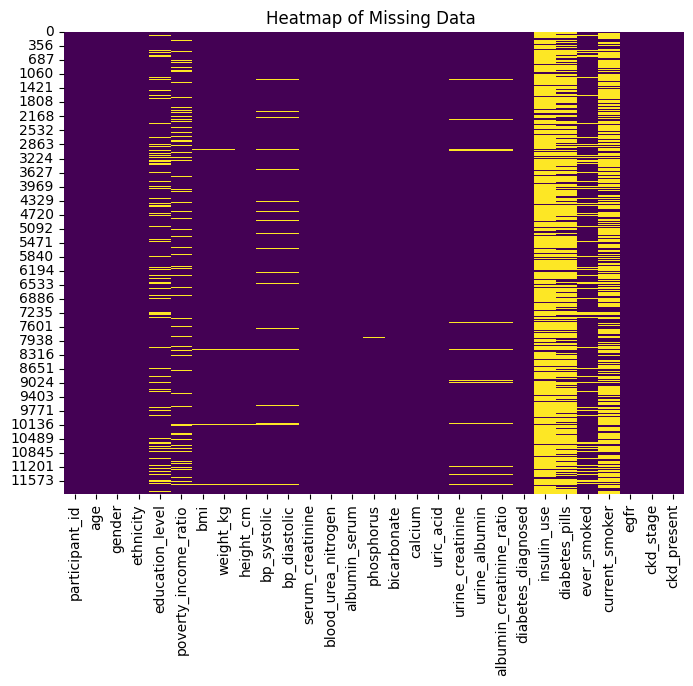

In [100]:
# Visualising the Missing Data with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap of Missing Data ")
plt.show()

Features related to diabetes medication (`insulin_use`, `diabetes_pills`) and smoking behaviour (`current_smoker`) showed huge missingness concentrated in the same observations.
This suggests data is Missing Not At Random (MNAR). Demographic features (`age`, `gender`, `ethnicity`) are fully 
available. These patterns informed imputation decisions.

#### Outliers and Duplicates 

In [101]:
# Create a new bmi column to check that the bmi was calculated correctly, using height and weight in the dataset
data.loc[:, 'check_bmi'] = data['weight_kg'] / (data['height_cm'] / 100)**2

In [102]:
data.loc[(data['bmi'] - data['check_bmi']).abs() > 0.1, ['bmi', 'check_bmi']]

,bmi,check_bmi


Bmi was calculated accurately.

In [103]:
# Creating a list of numerical variables for checking the outliers
numeric_cols = ['age', 'bmi', 'weight_kg', 'height_cm', 'bp_systolic', 'bp_diastolic','serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio']   

In [104]:
# Using the interquatile range method to identify outliers
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {outliers.shape[0]} outliers')

age: 0 outliers
bmi: 168 outliers
weight_kg: 141 outliers
height_cm: 10 outliers
bp_systolic: 131 outliers
bp_diastolic: 93 outliers
serum_creatinine: 183 outliers
blood_urea_nitrogen: 194 outliers
albumin_serum: 197 outliers
phosphorus: 142 outliers
bicarbonate: 111 outliers
calcium: 93 outliers
uric_acid: 87 outliers
urine_creatinine: 132 outliers
urine_albumin: 762 outliers
albumin_creatinine_ratio: 770 outliers


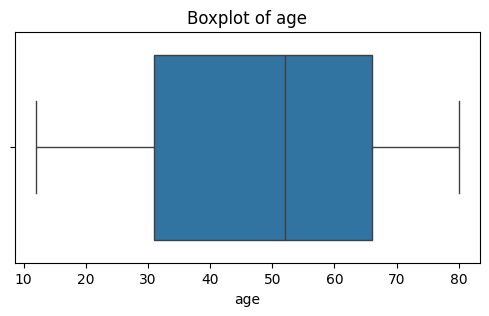

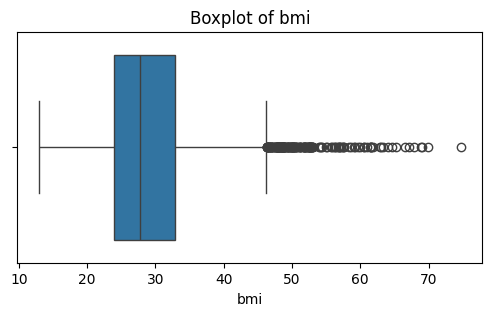

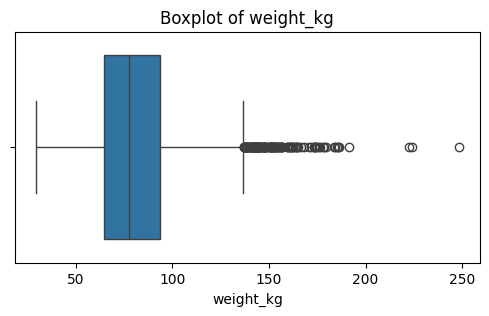

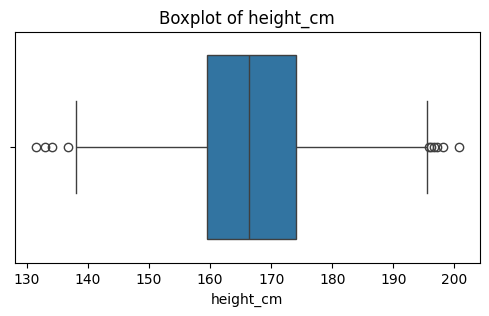

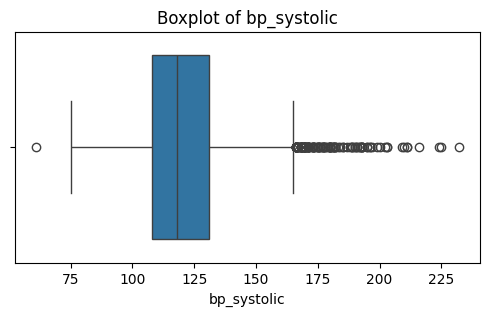

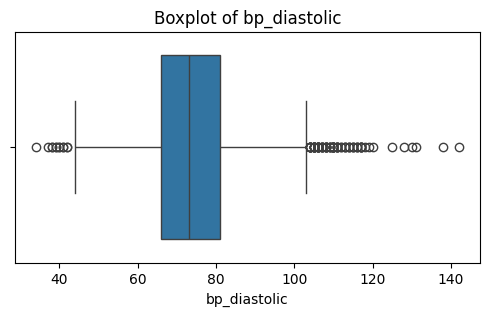

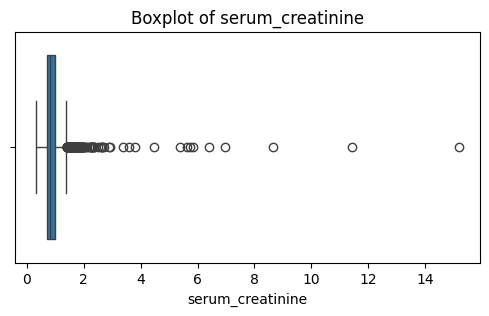

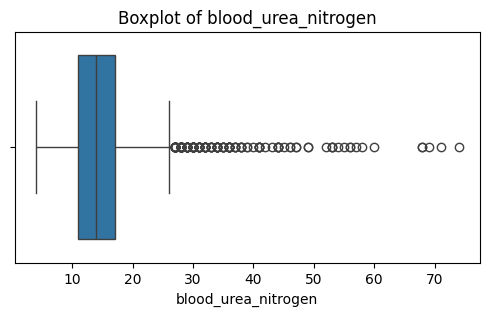

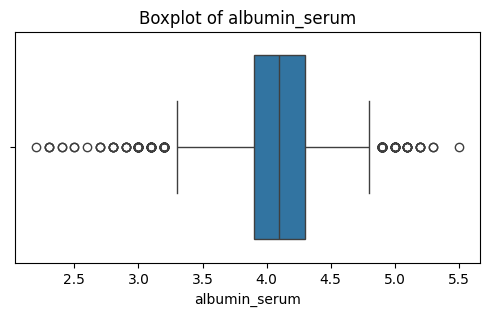

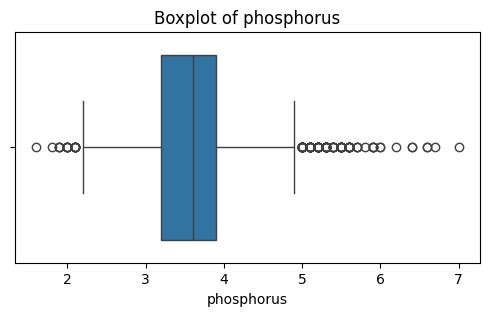

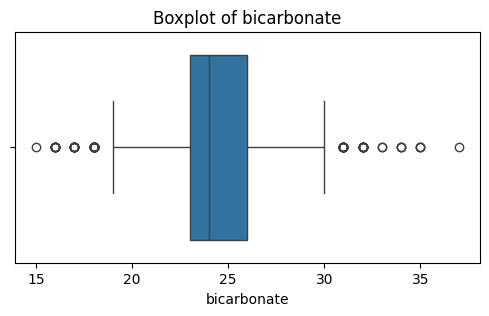

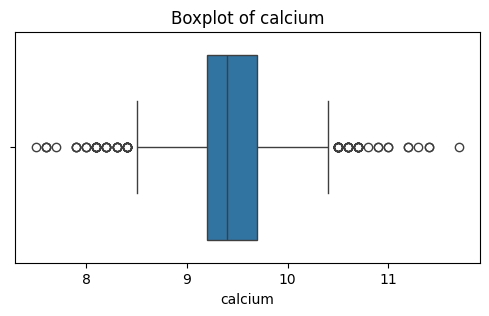

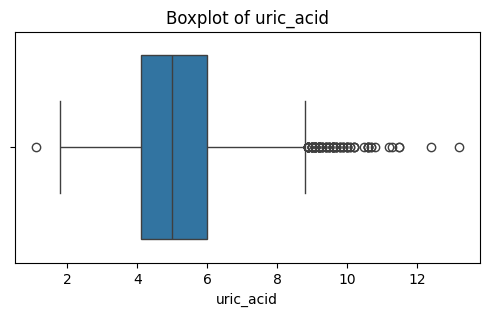

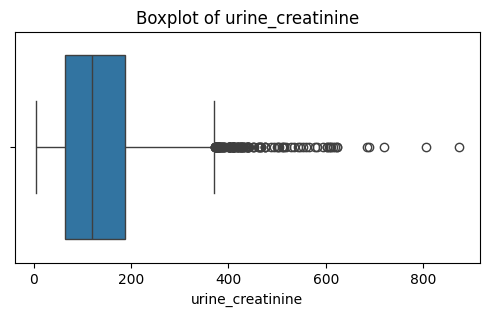

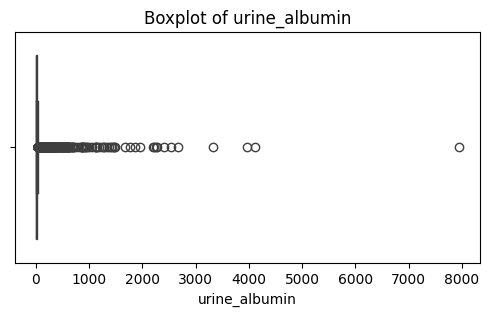

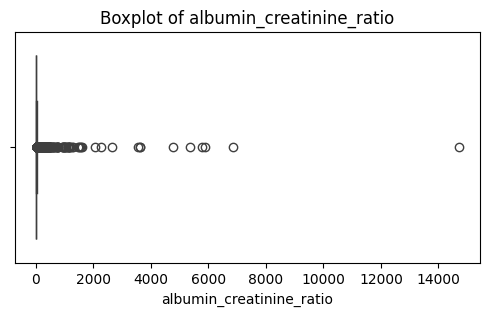

In [105]:
# Using boxplot to also view the outliers
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

'age' was the only variable with no outliers. The boxplots above showed that the remaining features have outliers. These observations will be assessed individually to determine whether the values are clinically plausible.
To further examine these extreme values, a high and low threshold of the numeric features, including the lab data was defined based on clinically acceptable ranges. These were informed by existing research. Some values were intentionally retained because  very high values relected advanced disease severity rather than data errors.

In [106]:
data.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0,26.970616
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0,33.546829
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0,29.685509
8,130386.0,34.0,Male,Mexican American,4.0,1.33,30.2,90.6,173.3,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,2.0,NaN,NaN,1.0,3.0,118.21,No CKD,0,30.166927
9,130387.0,68.0,Female,Non-Hispanic White,5.0,1.32,42.6,103.5,155.9,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,2.0,NaN,NaN,2.0,NaN,85.30,Stage 2 (Mildly Decreased),1,42.584163


In [107]:
# Data is not indexed. Resetting index 
data = data.reset_index(drop=True)

In [108]:
# Confirming data index has been reset
data.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0,26.970616
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0,33.546829
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0,29.685509
3,130386.0,34.0,Male,Mexican American,4.0,1.33,30.2,90.6,173.3,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,2.0,NaN,NaN,1.0,3.0,118.21,No CKD,0,30.166927
4,130387.0,68.0,Female,Non-Hispanic White,5.0,1.32,42.6,103.5,155.9,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,2.0,NaN,NaN,2.0,NaN,85.30,Stage 2 (Mildly Decreased),1,42.584163


In [109]:
# Defining the thresholds for numeric values
plausible_values = {
    'age' : (0, 100),
    'bmi' : (13, 75),
    'weight_kg' : (30, 250),
    'height_cm' : (120, 220),
    'bp_systolic' : (70, 230),
    'bp_diastolic' : (40, 140),
    'serum_creatinine' : (0.3, 15),
    'blood_urea_nitrogen' : (1, 150),
    'albumin_serum' : (1, 6),
    'phosphorus' : (1, 12),
    'bicarbonate' : (10, 45),
    'calcium' : (5, 16),
    'uric_acid' : (2, 18),
    'urine_creatinine' : (10, 600),
    'urine_albumin' : (0, 3500),
    'albumin_creatinine_ratio' : (0, 3500)
}

In [110]:
# This loop prints out the values the are lower than or higher than the 
# threshold specified in 'plausible_values'. 
# These will be inspected on a case by case basis.
for col in numeric_cols:
    low, high = plausible_values[col]
    print(f"{col} - values below {low}:")
    print(data[data[col] < low][col])
    print(f"{col} - values above {high}:")
    print(data[data[col] > high][col])
    print("-"*40)

age - values below 0:
Series([], Name: age, dtype: float64)
age - values above 100:
Series([], Name: age, dtype: float64)
----------------------------------------
bmi - values below 13:
5855    12.9
Name: bmi, dtype: float64
bmi - values above 75:
Series([], Name: bmi, dtype: float64)
----------------------------------------
weight_kg - values below 30:
5492    29.5
Name: weight_kg, dtype: float64
weight_kg - values above 250:
Series([], Name: weight_kg, dtype: float64)
----------------------------------------
height_cm - values below 120:
Series([], Name: height_cm, dtype: float64)
height_cm - values above 220:
Series([], Name: height_cm, dtype: float64)
----------------------------------------
bp_systolic - values below 70:
1834    61.0
Name: bp_systolic, dtype: float64
bp_systolic - values above 230:
1266    232.0
Name: bp_systolic, dtype: float64
----------------------------------------
bp_diastolic - values below 40:
844     39.0
2882    38.0
3107    38.0
4247    37.0
5617    34.0

In [111]:
# View 'bmi' outlier
data[data['bmi'] == 12.9]

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
5855,141391.0,15.0,Male,Non-Hispanic White,NaN,1.52,12.9,33.9,162.1,103.0,66.0,0.82,10.0,5.1,3.7,20.0,9.9,7.2,22.0,5.78,26.27,2.0,NaN,NaN,NaN,NaN,133.04,No CKD,0,12.901306


A bmi of **12.9** was observed in a **15** year old male. This value will be kept to retain the variability in real-world data. Also, the participant was likely severely underweight rather a data error.

In [112]:
# View 'bp_systolic' outlier
data[(data['bp_systolic'] == 61) | (data['bp_systolic'] == 232)]

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
1266,132760.0,60.0,Male,Non-Hispanic Black,4.0,0.83,NaN,NaN,182.0,232.0,116.0,8.66,44.0,4.1,6.4,28.0,11.3,5.1,11.0,645.62,5869.27,1.0,2.0,2.0,1.0,1.0,6.46,Stage 5 (Kidney Failure),1,NaN
1834,133817.0,12.0,Female,Non-Hispanic Black,NaN,NaN,25.6,59.7,152.6,61.0,41.0,0.57,14.0,4.1,5.3,24.0,9.6,3.9,202.0,10.57,5.23,2.0,NaN,NaN,NaN,NaN,140.14,No CKD,0,25.636886


- Participant **132760** with **bp_systolic** of **232** suggests a highly severe case with high serum creatinine and is on insulin and diabetes pills. This observation will be kept.
- The observation with a **bp_systolic** of 61 will be retained. Although this value is low, the participant was **12** years old, and such a measurement is not physiologically impossible in paediatric populations.

In [113]:
# Positions of 'diastolic_bp' outliers
diastolic_outliers = [844, 2882, 3107, 4247, 5617, 5795, 1689 ]

diastolic_outliers_df = data.loc[diastolic_outliers]
diastolic_outliers_df

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
844,131958.0,20.0,Male,Other Hispanic,4.0,0.70,25.6,75.7,171.9,108.0,39.0,1.13,21.0,4.3,4.3,26.0,9.6,5.3,144.0,11.88,8.25,2.0,NaN,NaN,2.0,NaN,95.43,No CKD,0,25.617935
2882,135853.0,80.0,Male,Non-Hispanic White,4.0,1.03,26.0,86.5,182.3,100.0,38.0,1.35,15.0,4.0,3.2,26.0,9.4,6.9,51.0,8.18,16.04,2.0,NaN,NaN,2.0,NaN,53.08,Stage 3a (Mild-Moderate),1,26.028118
3107,136280.0,12.0,Male,Non-Hispanic White,NaN,4.41,17.3,39.6,151.4,92.0,38.0,0.54,13.0,4.6,4.2,24.0,9.9,3.7,145.0,20.40,14.07,2.0,NaN,NaN,NaN,NaN,153.77,No CKD,0,17.276010
4247,138353.0,80.0,Female,Other Hispanic,2.0,1.81,21.0,46.2,148.2,98.0,37.0,0.77,25.0,3.9,3.5,25.0,9.6,4.2,112.0,40.91,36.53,1.0,1.0,1.0,2.0,NaN,77.93,Stage 2 (Mildly Decreased),1,21.035148
5617,140955.0,12.0,Male,Non-Hispanic Black,NaN,1.09,16.1,43.0,163.3,111.0,34.0,0.66,7.0,4.3,4.4,24.0,9.1,3.6,229.0,19.64,8.58,2.0,NaN,NaN,NaN,NaN,144.73,No CKD,0,16.124865
5795,141289.0,80.0,Male,Non-Hispanic White,5.0,1.91,23.1,74.4,179.5,95.0,39.0,1.15,32.0,3.6,3.6,23.0,9.3,4.7,128.0,14.46,11.30,2.0,NaN,NaN,2.0,NaN,64.34,Stage 2 (Mildly Decreased),1,23.091069
1689,133541.0,46.0,Female,Non-Hispanic White,3.0,1.41,36.6,98.3,163.9,182.0,142.0,0.73,21.0,3.9,3.7,20.0,9.4,5.3,30.0,117.31,391.03,1.0,2.0,1.0,1.0,3.0,102.65,Stage 1 (Kidney Damage),1,36.592797


In order to preserve data integrity, these values will also be retained considering age, body size and CKD status. 

In [114]:
serum_creatinine_outliers = [3301]

serum_creatinine_outliers_df = data.loc[serum_creatinine_outliers]
serum_creatinine_outliers_df

    

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
3301,136629.0,50.0,Male,Non-Hispanic Asian,5.0,1.26,27.4,79.9,170.7,139.0,71.0,15.17,52.0,3.9,6.6,23.0,8.6,7.7,54.0,7942.47,14708.28,1.0,1.0,2.0,1.0,3.0,3.51,Stage 5 (Kidney Failure),1,27.420776


A value of **15.7** is high but the participant is at stage 5 (kidney failure) of CKD. Hence, they are very sick and this outlier will be kept.

In [115]:
urine_creatinine_outliers = [32, 465, 842, 1061, 1495, 1625, 1727, 2255, 2961, 3647,
                            3800, 4693 ,5176, 5259,5883 ,5896, 317, 705, 1066, 2229, 2835,2987,
                            3432, 3473, 4208, 4481, 4916,5202,5271, 6137]


urine_creatinine_outliers_df = data.loc[urine_creatinine_outliers]
urine_creatinine_outliers_df

    

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present,check_bmi
32,130430.0,27.0,Female,Non-Hispanic White,5.0,3.43,22.2,63.0,168.5,118.0,68.0,0.71,10.0,4.5,3.8,24.0,9.9,4.3,7.0,0.21,3.00,2.0,NaN,NaN,2.0,NaN,119.44,No CKD,0,22.189154
465,131221.0,13.0,Female,Non-Hispanic White,NaN,3.42,19.9,43.8,148.3,83.0,53.0,0.50,7.0,3.9,4.1,25.0,9.5,2.8,5.0,0.21,4.20,2.0,NaN,NaN,NaN,NaN,143.74,No CKD,0,19.915527
842,131948.0,34.0,Female,Non-Hispanic White,5.0,4.33,18.3,50.2,165.4,113.0,61.0,0.67,20.0,4.4,4.3,27.0,9.8,4.0,9.0,0.21,2.33,2.0,NaN,NaN,2.0,NaN,117.55,No CKD,0,18.349858
1061,132383.0,73.0,Female,Non-Hispanic White,4.0,1.47,18.1,47.7,162.3,116.0,61.0,0.69,16.0,4.1,3.6,26.0,9.9,4.4,8.0,0.21,2.63,2.0,NaN,NaN,1.0,1.0,91.58,No CKD,0,18.108453
1495,133161.0,51.0,Female,Non-Hispanic White,3.0,NaN,24.6,65.2,162.8,120.0,71.0,0.66,10.0,4.2,3.0,25.0,9.8,3.6,7.0,0.21,3.00,2.0,NaN,NaN,2.0,NaN,106.14,No CKD,0,24.600209
1625,133413.0,18.0,Female,Non-Hispanic White,NaN,0.11,21.0,60.1,169.3,119.0,75.0,0.72,11.0,4.0,3.3,27.0,9.4,4.2,8.0,0.21,2.63,2.0,NaN,NaN,2.0,NaN,124.21,No CKD,0,20.968171
1727,133598.0,62.0,Female,Non-Hispanic White,4.0,2.21,25.3,70.3,166.6,124.0,71.0,0.53,10.0,4.1,3.5,23.0,9.5,3.8,7.0,0.21,3.00,2.0,NaN,NaN,1.0,3.0,104.50,No CKD,0,25.328259
2255,134609.0,14.0,Female,Non-Hispanic White,NaN,2.92,19.8,53.3,163.9,115.0,67.0,0.57,8.0,4.4,4.2,22.0,9.8,4.8,8.0,4.38,54.75,2.0,NaN,NaN,NaN,NaN,138.41,Stage 1 (Kidney Damage),1,19.841262
2961,136008.0,13.0,Female,Mexican American,NaN,0.57,32.3,75.7,153.0,106.0,67.0,0.65,11.0,4.2,4.5,22.0,9.4,3.2,5.0,0.21,4.20,2.0,NaN,NaN,NaN,NaN,134.93,No CKD,0,32.337990
3647,137263.0,57.0,Female,Other Hispanic,1.0,0.92,24.1,54.4,150.1,156.0,92.0,0.53,11.0,3.5,3.9,21.0,8.5,4.5,6.0,61.77,1029.50,1.0,2.0,1.0,2.0,NaN,107.80,Stage 1 (Kidney Damage),1,24.145573


For the laboratory measurements (e.g serum_creatinine, urine_creatinine and others), the outliers will be untouched due to severe illness like kidney failure. These values will not be removed in order to avoid bias. 

In [116]:
# Checking duplicates
duplicates = data.duplicated()
print(f'Number of duplicate rows: {duplicates.sum()}')


Number of duplicate rows: 0


#### Feature Dropping

The following features were removed prior to analysis:

| Feature | Reason for Removal |
|---|---|
| `participant_id` | Identifier is non-informative |
| `ckd_stage` | Multiclass target — not relevant for binary classification task |
| `egfr` | Primary metric used to derive the `ckd_present` label;retaining causes data leakage |
| `serum_creatinine`, `urine_albumin`, `albumin_creatinine_ratio` | Direct CKD diagnostic criteria per KDIGO 2012 guidelines — inclusion causes data leakage |
| `blood_urea_nitrogen`, `urine_creatinine` | Strong clinical indicators of CKD — inclusion produced implausibly high accuracy (>99%), indicative of data leakage |
| `weight_kg`, `height_cm` | BMI already derived from these; dropped to remove multicollinearity |
| `insulin_use`, `diabetes_pills`, `current_smoker` | >60% missing — imputation would introduce significant bias; clinical information captured by  `diabetes_diagnosed` and `ever_smoked`

In [117]:
data = data.drop(columns=['participant_id', 'weight_kg', 'height_cm', 'insulin_use',
                          'diabetes_pills', 'current_smoker', 'ckd_stage', 'check_bmi'])

In [118]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       6326 non-null   float64
 1   gender                    6326 non-null   object 
 2   ethnicity                 6326 non-null   object 
 3   education_level           5443 non-null   float64
 4   poverty_income_ratio      5483 non-null   float64
 5   bmi                       6245 non-null   float64
 6   bp_systolic               6133 non-null   float64
 7   bp_diastolic              6133 non-null   float64
 8   serum_creatinine          6326 non-null   float64
 9   blood_urea_nitrogen       6323 non-null   float64
 10  albumin_serum             6326 non-null   float64
 11  phosphorus                6307 non-null   float64
 12  bicarbonate               6323 non-null   float64
 13  calcium                   6322 non-null   float64
 14  uric_aci

#### Checking Data Distribution and Relationships

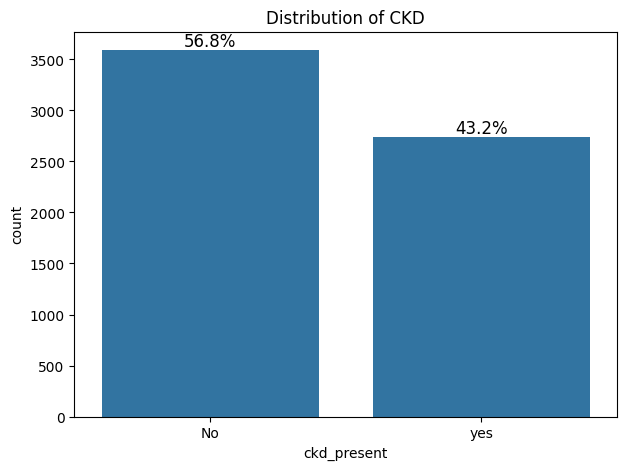

In [119]:
# Distribution of target variable
ckd_label = data['ckd_present'].map({0: 'No', 1: 'yes'})

plt.figure(figsize=(7, 5))
ax = sns.countplot(x=ckd_label)

total = len(data)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom', fontsize=12)

plt.title('Distribution of CKD')
plt.show()

The dataset has a slight class imbalance, with a **43:57** distribution between CKD-positive 
and CKD-negative cases. Although not perfectly balanced, this does not represent severe class imbalance in a clinical context, and no resampling 
technique was applied. Introducing synthetic oversampling such as SMOTE risks generating 
observations that do not reflect real participant data which could compromise clinical 
validity and distort the true data distribution. 


In [120]:
# View the values in the categorical variables.
for col in ['gender', 'ethnicity', 'education_level', 'diabetes_diagnosed', 
            'ever_smoked']:
    print(f'Value counts for {col}:')
    print(data[col].value_counts(dropna=False))
    print('-' * 20)

Value counts for gender:
gender
Female    3428
Male      2898
Name: count, dtype: int64
--------------------
Value counts for ethnicity:
ethnicity
Non-Hispanic White    3603
Non-Hispanic Black     754
Other Hispanic         703
Mexican American       506
Other/Multiracial      411
Non-Hispanic Asian     349
Name: count, dtype: int64
--------------------
Value counts for education_level:
education_level
5.0    1992
4.0    1663
3.0    1120
NaN     883
2.0     413
1.0     253
9.0       2
Name: count, dtype: int64
--------------------
Value counts for diabetes_diagnosed:
diabetes_diagnosed
2.0    5356
1.0     766
3.0     203
9.0       1
Name: count, dtype: int64
--------------------
Value counts for ever_smoked:
ever_smoked
2.0    3412
1.0    2237
NaN     670
9.0       4
7.0       3
Name: count, dtype: int64
--------------------


In NHANES survey data, codes `7` and `9` represent 'Refused' and 'Don't Know' respectively. 
These were recoded as missing values to prevent skewing the data. Also, the value `3` in `diabetes_diagnosed` represents borderline/pre-diabetes. These were recoded as `0` (not 
diagnosed), as pre-diabetes does not constitute a clinical CKD diagnosis.

In [121]:
# missing
# Replace 7 and 9 with nan and verify
cols_to_replace = ['education_level', 'diabetes_diagnosed', 'ever_smoked']

data[cols_to_replace] = data[cols_to_replace].replace({7: np.nan, 9: np.nan})

#replace 3 with 2 in diabetes_diagnosed column 
data['diabetes_diagnosed'] = data['diabetes_diagnosed'].replace(3, 2)

# Verify the unique values
for col in ['gender', 'ethnicity', 'education_level', 'diabetes_diagnosed', 
            'ever_smoked']:
    print(f'Value counts for {col}:')
    print(data[col].value_counts(dropna=False))
    print('-' * 20)

Value counts for gender:
gender
Female    3428
Male      2898
Name: count, dtype: int64
--------------------
Value counts for ethnicity:
ethnicity
Non-Hispanic White    3603
Non-Hispanic Black     754
Other Hispanic         703
Mexican American       506
Other/Multiracial      411
Non-Hispanic Asian     349
Name: count, dtype: int64
--------------------
Value counts for education_level:
education_level
5.0    1992
4.0    1663
3.0    1120
NaN     885
2.0     413
1.0     253
Name: count, dtype: int64
--------------------
Value counts for diabetes_diagnosed:
diabetes_diagnosed
2.0    5559
1.0     766
NaN       1
Name: count, dtype: int64
--------------------
Value counts for ever_smoked:
ever_smoked
2.0    3412
1.0    2237
NaN     677
Name: count, dtype: int64
--------------------


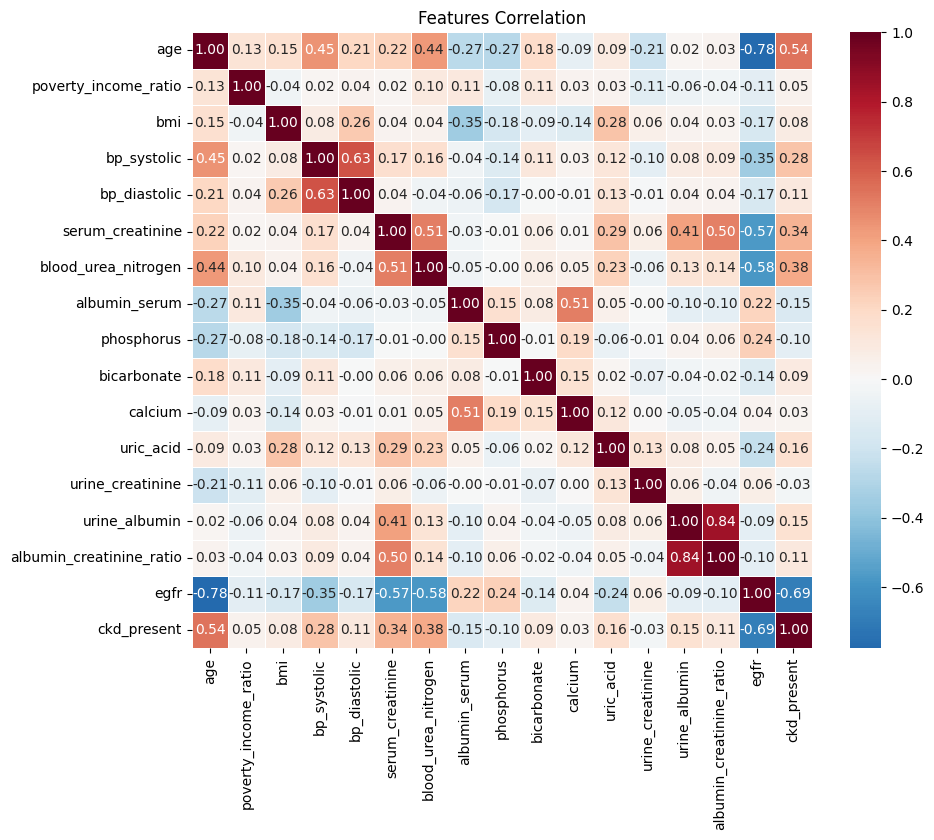

In [122]:
# Checking features correlation
cols_for_corr = ['age', 'poverty_income_ratio', 'bmi', 'bp_systolic','bp_diastolic','serum_creatinine',
                 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate','calcium',
                  'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr','ckd_present']

corr_matrix = data[cols_for_corr].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='RdBu_r',
           center=0,
           annot=True,
           fmt='.2f',
           linewidths=0.5)

plt.title('Features Correlation')
plt.show()



Correlation analysis showed multicollinearity among several features, especially diagnostic 
variables. For instance, `urine_albumin` and `albumin_creatinine_ratio` (r = 0.84). Age showed a 
strong correlation with 'egfr' (r = 0.78), and `egfr` was highly correlated 
with `ckd_present` (r = 0.69), further justifying its removal due to data leakage.

In [123]:

#Redefining  columns
numerical_cols = ['age', 'poverty_income_ratio', 'bmi', 'bp_systolic','bp_diastolic','serum_creatinine',
                 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate','calcium',
                  'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio']

# Categorical columns
categorical_cols = ['gender', 'ethnicity', 'education_level', 'diabetes_diagnosed', 'ever_smoked']

In [124]:

# Makin a temporary copy for plotting graphs
data_plot = data.copy()


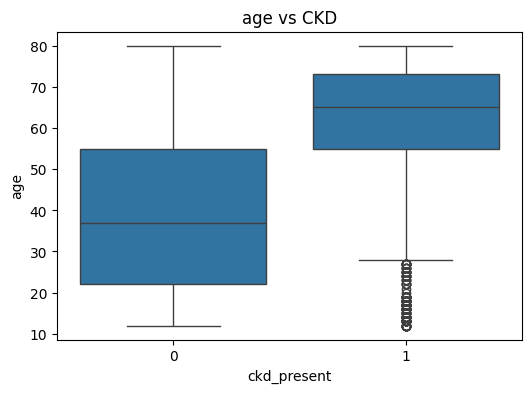

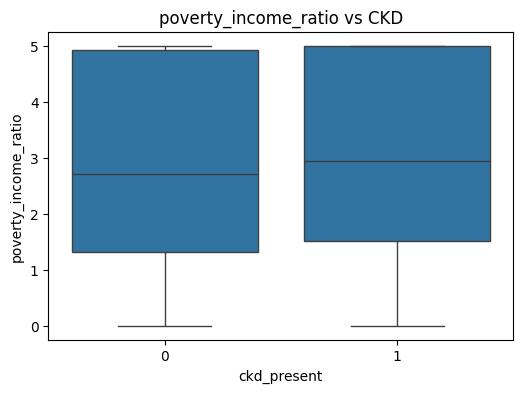

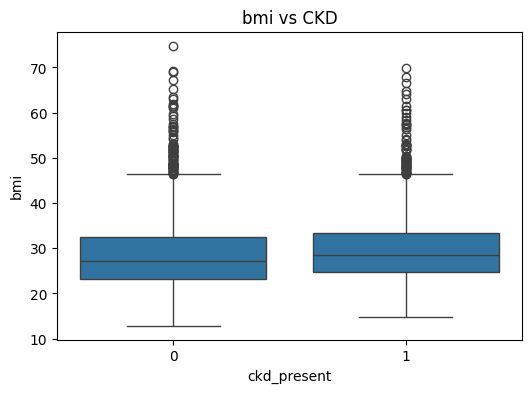

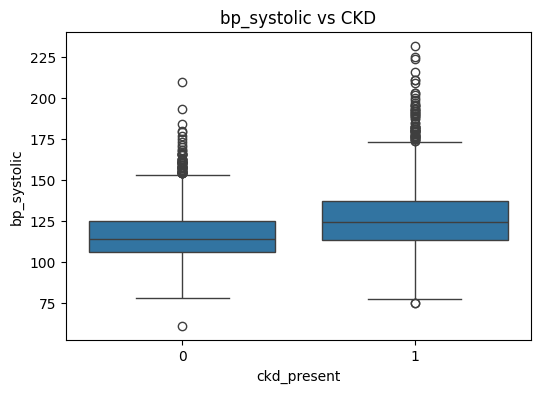

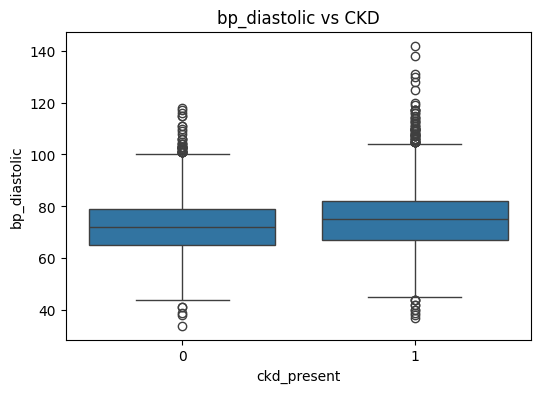

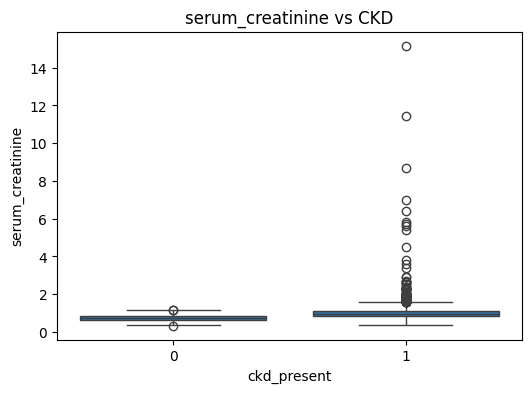

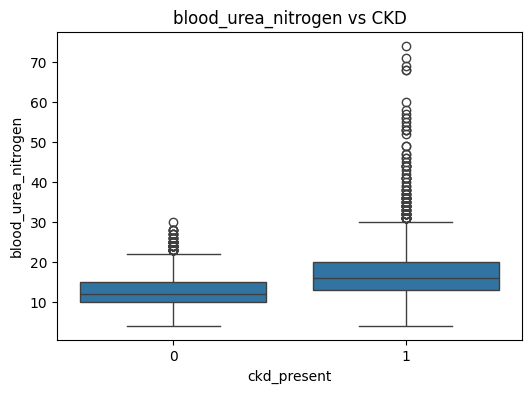

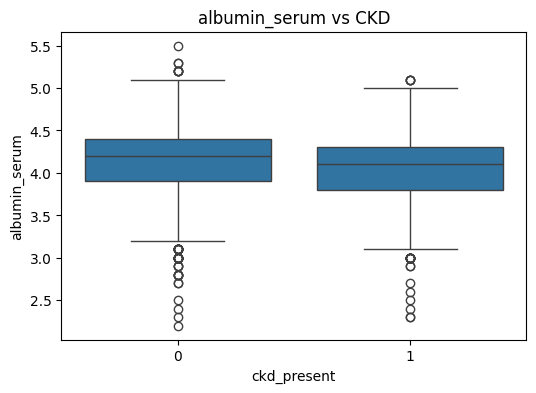

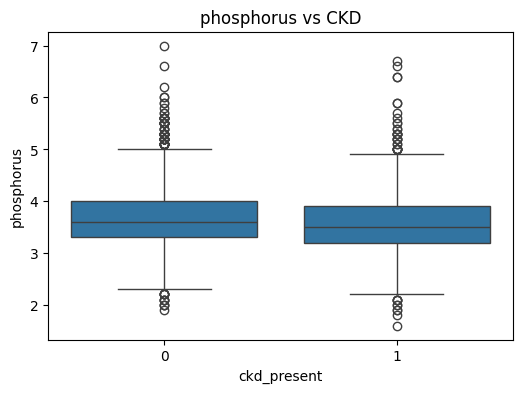

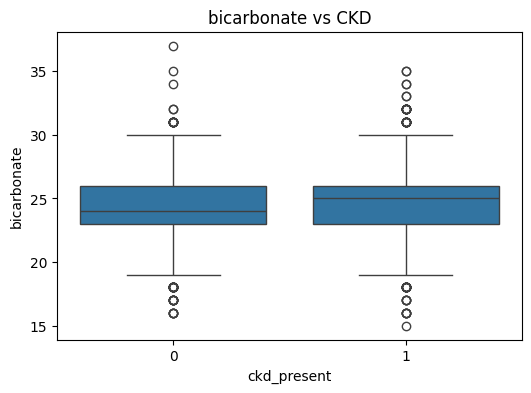

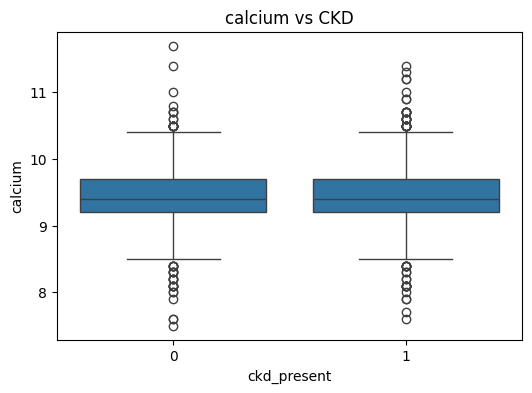

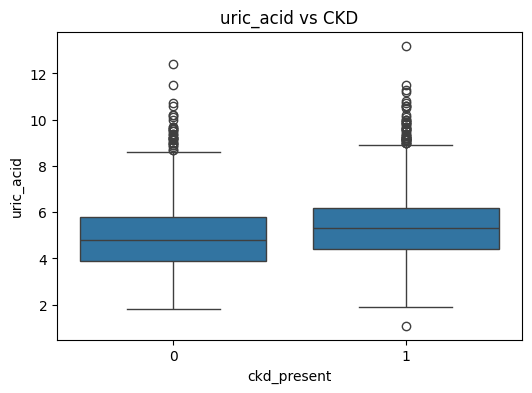

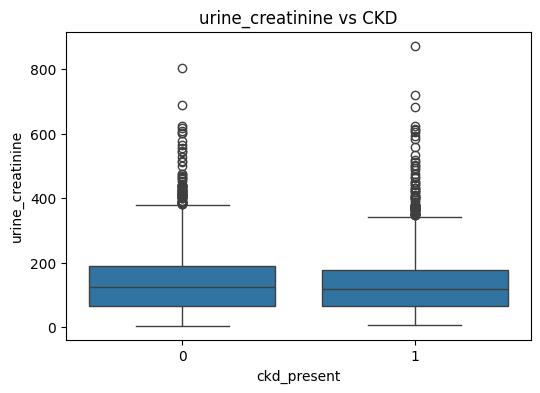

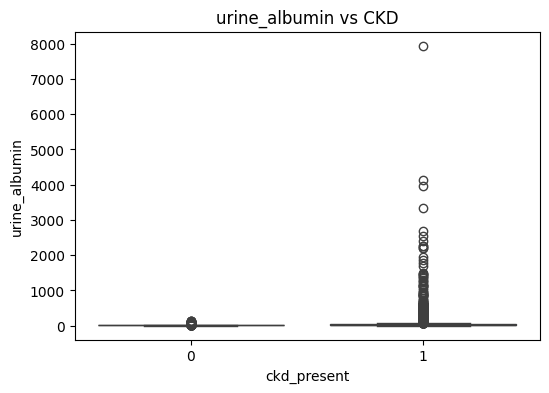

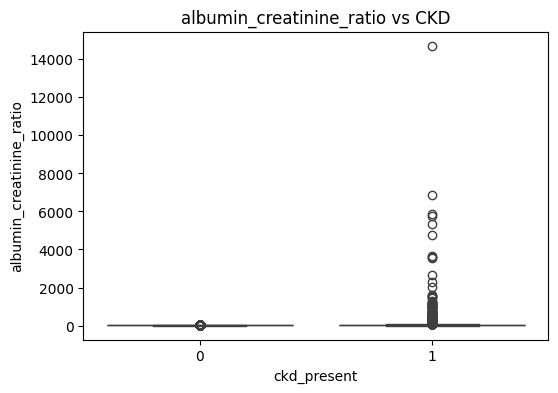

In [125]:

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='ckd_present', y=col, data=data_plot)
    plt.title(f'{col} vs CKD')
    plt.show()

**Numerical Features — Key Observations**

Age was the strongest differentiator — CKD participants clustered in the late 50s and 60s, 
which aligns with age-related decline in kidney function. Younger participants with CKD were also 
present, potentially due to genetic causes.

Blood pressure distributions overlapped between groups, although CKD participants 
showed a greater proportion of readings above 150 mmHg. This may suggest an association with 
hypertension. 

BMI did not clearly differentiate between CKD and non-CKD groups, with similar median values. 

Laboratory values (e.g. serum creatinine, blood urea nitrogen) were in a small range. These data points represent people with kidneys struggling to filter waste causing a significant buildup oin the blood.

In [126]:

# data_plot['gender_label'] = data_plot['gender'],replace({1: 'Male', 2: 'Female'})

data_plot['diabetes_label'] = data_plot['diabetes_diagnosed'].replace({1: 'Diabetic', 2: 'Non-Diabetic'})

data_plot['education_label'] = data_plot['education_level'].replace({1: '< 9th Grade', 2: '9-11th Grade', 3: 'High School Graduate', 4: 'Some College', 5: 'College Graduate'})

data_plot['smoked_label'] = data_plot['ever_smoked'].replace({1: 'Yes', 2: 'No'}).fillna('Missing')

# data_plot['ethnicity_label'] = data_plot['ethnicity'],replace({1: '< 9th grade', 2: '9-11th grade', 3: 'High school grade', 4: 'Some college', 5: 'College graduate'})


In [127]:
data_plot['ckd_label'] = data['ckd_present'].map({0:'No CKD', 1: 'CKD'})

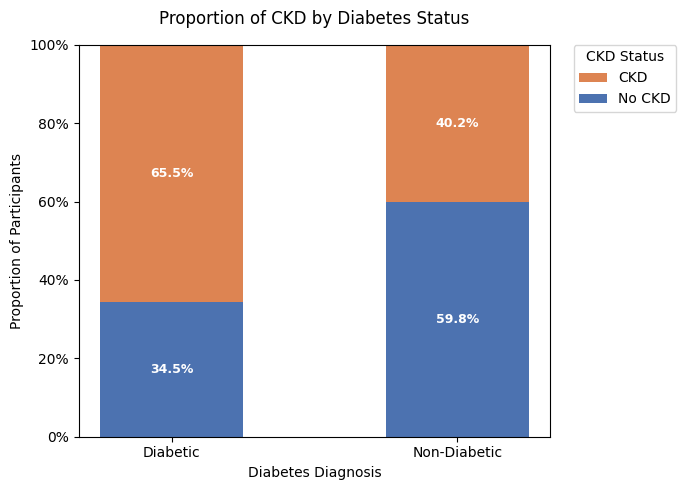

In [128]:
# Creating proportions of participants with/without diabetes
prop_df = (
    data_plot
    .groupby(['diabetes_label', 'ckd_label'], as_index=False)
    .size()
)

prop_df['proportion'] = (
    prop_df
    .groupby('diabetes_label')['size']
    .transform(lambda x: x / x.sum())
)

# Pivot for stacked bar chart
pivot_df = prop_df.pivot(
    index='diabetes_label', 
    columns='ckd_label', 
    values='proportion'
).fillna(0)

# Reverse column order so CKD sits on top, No CKD at bottom
pivot_df = pivot_df[pivot_df.columns[::-1]]

# Plotting 100% stacked bar chart
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(pivot_df))
colors = ['#4C72B0', '#DD8452']  # No CKD (blue) bottom, CKD (orange) top

for i, col in enumerate(pivot_df.columns):
    values = pivot_df[col].values
    bars = ax.bar(
        pivot_df.index, 
        values, 
        bottom=bottom, 
        label=col, 
        color=colors[i],
        width=0.5
    )
    # Add percentage labels inside bars
    for j, (val, bot) in enumerate(zip(values, bottom)):
        if val > 0.03:  # only label if bar is big enough to read
            ax.text(
                j, bot + val / 2, 
                f'{val*100:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += values

# Formatting
ax.set_title('Proportion of CKD by Diabetes Status', pad=15)
ax.set_xlabel('Diabetes Diagnosis')
ax.set_ylabel('Proportion of Participants')
ax.yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
ax.set_ylim(0, 1)

# Reverse legend order to match stack (CKD on top)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    title='CKD Status', 
    bbox_to_anchor=(1.05, 1),
    loc='upper left', 
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

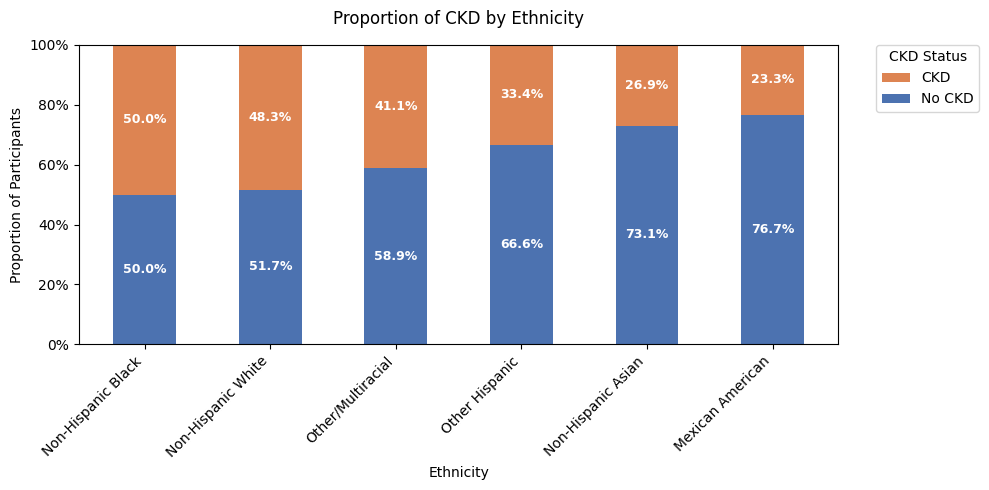

In [129]:
# Creating proportions by ethnicity
eth_prop = (
    data_plot
    .groupby(['ethnicity', 'ckd_label'], as_index=False)
    .size()
)

eth_prop['proportion'] = (
    eth_prop
    .groupby('ethnicity')['size']
    .transform(lambda x: x / x.sum())
)

# Sort ethnicities by CKD proportion descending
ckd_order = (
    eth_prop[eth_prop['ckd_label'] == 'CKD']
    .sort_values('proportion', ascending=False)['ethnicity']
    .tolist()
)

# Pivot for stacked bar chart
pivot_eth = eth_prop.pivot(
    index='ethnicity',
    columns='ckd_label',
    values='proportion'
).fillna(0)

# Reorder rows by descending CKD proportion
pivot_eth = pivot_eth.loc[ckd_order]

# Reverse column order so CKD sits on top, No CKD at bottom
pivot_eth = pivot_eth[pivot_eth.columns[::-1]]

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(pivot_eth))
colors = ['#4C72B0', '#DD8452']  # No CKD (blue) bottom, CKD (orange) top

for i, col in enumerate(pivot_eth.columns):
    values = pivot_eth[col].values
    ax.bar(
        pivot_eth.index,
        values,
        bottom=bottom,
        label=col,
        color=colors[i],
        width=0.5
    )
    for j, (val, bot) in enumerate(zip(values, bottom)):
        if val > 0.03:
            ax.text(
                j, bot + val / 2,
                f'{val*100:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += values

# Formatting
ax.set_title('Proportion of CKD by Ethnicity', pad=15)
ax.set_xlabel('Ethnicity')
ax.set_ylabel('Proportion of Participants')
ax.yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    title='CKD Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

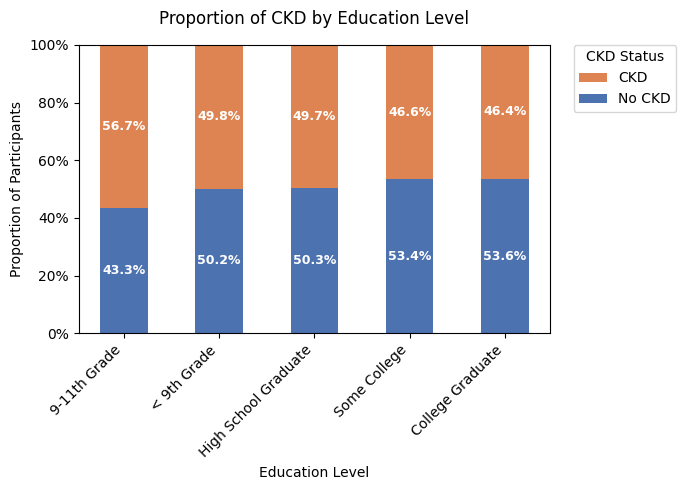

In [130]:
# Creating proportions by education level
edu_prop = (
    data_plot
    .groupby(['education_label', 'ckd_label'], as_index=False)
    .size()
)

edu_prop['proportion'] = (
    edu_prop
    .groupby('education_label')['size']
    .transform(lambda x: x / x.sum())
)

# Sort by CKD proportion descending
ckd_order = (
    edu_prop[edu_prop['ckd_label'] == 'CKD']
    .sort_values('proportion', ascending=False)['education_label']
    .tolist()
)

# Pivot for stacked bar chart
pivot_edu = edu_prop.pivot(
    index='education_label',
    columns='ckd_label',
    values='proportion'
).fillna(0)

# Reorder and reverse columns
pivot_edu = pivot_edu.loc[ckd_order]
pivot_edu = pivot_edu[pivot_edu.columns[::-1]]

# Plotting
fig, ax = plt.subplots(figsize=(7, 5))

bottom = np.zeros(len(pivot_edu))
colors = ['#4C72B0', '#DD8452']  # No CKD (blue) bottom, CKD (orange) top

for i, col in enumerate(pivot_edu.columns):
    values = pivot_edu[col].values
    ax.bar(
        pivot_edu.index,
        values,
        bottom=bottom,
        label=col,
        color=colors[i],
        width=0.5
    )
    for j, (val, bot) in enumerate(zip(values, bottom)):
        if val > 0.03:
            ax.text(
                j, bot + val / 2,
                f'{val*100:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9, fontweight='bold'
            )
    bottom += values

# Formatting
ax.set_title('Proportion of CKD by Education Level', pad=15)
ax.set_xlabel('Education Level')
ax.set_ylabel('Proportion of Participants')
ax.yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    title='CKD Status',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

plt.tight_layout()
plt.show()

### Imputation

Three techniques of imputation were tested. Simple imputation, KNN and MICE imputation

In [131]:
# Checking for Missing Values in Percentage 
print("\nPercentage of Missing Values after Removing Features:")
new_missing_percent = (data.isnull().sum() / len(data)) * 100

# Showing only columns that have missing values
new_missing_percent = new_missing_percent[new_missing_percent > 0 ].sort_values(ascending=False)

print(new_missing_percent)


Percentage of Missing Values after Removing Features:
education_level             13.989883
poverty_income_ratio        13.325956
ever_smoked                 10.701865
bp_systolic                  3.050901
bp_diastolic                 3.050901
urine_albumin                1.960164
albumin_creatinine_ratio     1.960164
urine_creatinine             1.944357
bmi                          1.280430
phosphorus                   0.300348
calcium                      0.063231
blood_urea_nitrogen          0.047423
bicarbonate                  0.047423
diabetes_diagnosed           0.015808
dtype: float64


In [132]:
numerical_features = ['age', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'serum_creatinine',
                  'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid',
                  'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'egfr']

categorical_features = ['gender', 'ethnicity', 'education_level', 'diabetes_diagnosed', 'ever_smoked', 'ckd_present']

num_data = data[numerical_features].copy()
cat_data = data[categorical_features].drop(columns=['ckd_present']).copy()

In [133]:
# Impute missing values in the categorical columns with the mode
simple_imputer_cat = SimpleImputer(strategy='most_frequent')

simple_cat_imputed = pd.DataFrame(simple_imputer_cat.fit_transform(cat_data), columns=cat_data.columns)

print("\nData After Simple Imputation:")
simple_cat_imputed.head()


Data After Simple Imputation:


,gender,ethnicity,education_level,diabetes_diagnosed,ever_smoked
0,Male,Non-Hispanic Asian,5.0,2.0,1.0
1,Male,Non-Hispanic White,5.0,2.0,1.0
2,Female,Other Hispanic,3.0,1.0,2.0
3,Male,Mexican American,4.0,2.0,1.0
4,Female,Non-Hispanic White,5.0,2.0,2.0


In [134]:
# Impute missaing values in the numerical columns with median
simple_imputer = SimpleImputer(strategy='median')

simple_num_imputed = pd.DataFrame(simple_imputer.fit_transform(num_data), columns=num_data.columns)

print("\nData After Simple Imputation:")
simple_num_imputed.head()


Data After Simple Imputation:


,age,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr
0,43.0,5.00,27.0,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,112.61
1,66.0,5.00,33.5,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,97.98
2,44.0,1.41,29.7,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,111.69
3,34.0,1.33,30.2,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,118.21
4,68.0,1.32,42.6,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,85.30


In [135]:
# KNN Imputation

# Impute Missing Values Using K-Nearest Neighbors
knn_imputer = KNNImputer(n_neighbors=5)

knn_num_imputed = pd.DataFrame(knn_imputer.fit_transform(num_data), columns=num_data.columns)

print("\nData After KNN Imputation:")
knn_num_imputed.head()


Data After KNN Imputation:


,age,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr
0,43.0,5.00,27.0,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,112.61
1,66.0,5.00,33.5,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,97.98
2,44.0,1.41,29.7,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,111.69
3,34.0,1.33,30.2,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,118.21
4,68.0,1.32,42.6,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,85.30


In [136]:
# Multivariate Imputation by Chained Equations (MICE)

# Impute Missing Values Using Iterative Imputer (MICE)
iterative_imputer = IterativeImputer(max_iter=10, random_state=42)

mice_num_imputed = pd.DataFrame(iterative_imputer.fit_transform(num_data), columns=num_data.columns)

print("\nData After MICE Imputation:")
mice_num_imputed.head()


Data After MICE Imputation:


c:\Users\HALIMAT\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,age,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr
0,43.0,5.00,27.0,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,112.61
1,66.0,5.00,33.5,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,97.98
2,44.0,1.41,29.7,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,111.69
3,34.0,1.33,30.2,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,118.21
4,68.0,1.32,42.6,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,85.30


In [137]:
# Comparison of Imputation Techniques

# Compare Original and Imputed Data (Mean and Variance)
original_means = num_data.mean()
median_means = simple_num_imputed.mean()
knn_means = knn_num_imputed.mean()
mice_means = mice_num_imputed.mean()

mean_comparison = pd.DataFrame({
    "Original Mean": original_means,
    "Median Imputed Mean": median_means,
    "KNN Imputed Mean": knn_means,
    "MICE Imputed Mean": mice_means
})

print("\nComparison of Means Before and After Imputation:")
print(mean_comparison)

 
original_var = num_data.var()
median_var = simple_num_imputed.var()
knn_var = knn_num_imputed.var()
mice_var = mice_num_imputed.var()

variance_comparison = pd.DataFrame({
    "Original Var": original_var,
    "Median Var": median_var,
    "KNN Var": knn_var,
    "MICE Var": mice_var
})

print("\nComparison of Variance:")
print(variance_comparison)


Comparison of Means Before and After Imputation:
                          Original Mean  Median Imputed Mean  KNN Imputed Mean  MICE Imputed Mean
age                           48.623775            48.623775         48.623775          48.623775
poverty_income_ratio           2.908430             2.893980          2.909933           2.908129
bmi                           29.077646            29.061287         29.080411          29.081334
bp_systolic                  120.718409           120.635473        120.665918         120.686447
bp_diastolic                  73.753302            73.730319         73.702845          73.761131
serum_creatinine               0.872828             0.872828          0.872828           0.872828
blood_urea_nitrogen           14.662186            14.661872         14.662251          14.662417
albumin_serum                  4.098925             4.098925          4.098925           4.098925
phosphorus                     3.608070             3.608046        

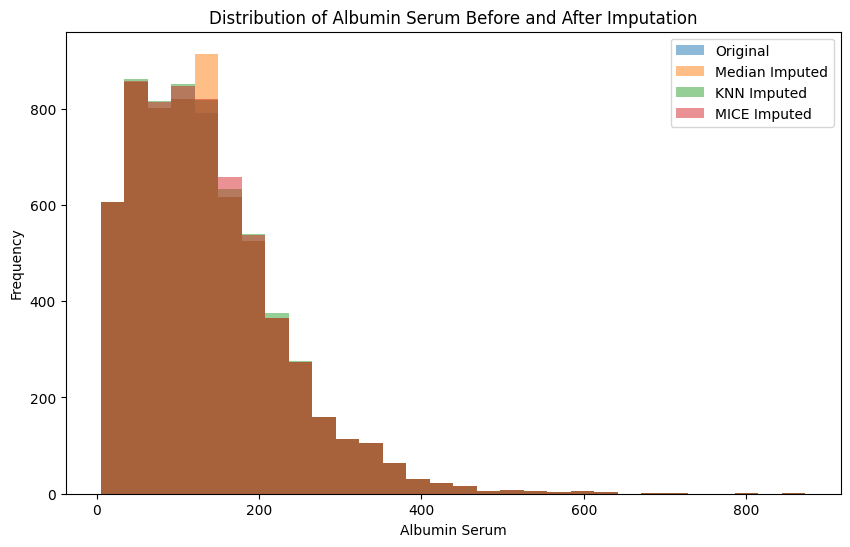

In [138]:


# Visualizing distribution of a variable before and after imputation
column_to_visualize = 'urine_creatinine'  # Replace with the column you want to visualize

plt.figure(figsize=(10, 6))

plt.hist(num_data[column_to_visualize].dropna(), bins=30, alpha=0.5, label="Original")
plt.hist(simple_num_imputed[column_to_visualize], bins=30, alpha=0.5, label="Median Imputed")
plt.hist(knn_num_imputed[column_to_visualize], bins=30, alpha=0.5, label="KNN Imputed")
plt.hist(mice_num_imputed[column_to_visualize], bins=30, alpha=0.5, label="MICE Imputed")
plt.title("Distribution of Albumin Serum Before and After Imputation")
plt.xlabel('Albumin Serum')
plt.ylabel("Frequency")
plt.legend()
plt.show()

There was minimal distributional shift across most features after imputation, suggesting 
missingness did not substantially skew the dataset. Median imputation reduced variability by 
assigning a single value to all missing observations. This produced an artificial peak in the 
distribution. MICE was preferred as it treats each missing value as a prediction conditioned 
on other features, preserving the natural variability of the data (Joel et al., 2025).

In [139]:
# Re-indexing imputed data 
mice_num_imputed.index = data.index
simple_cat_imputed.index = data.index

In [140]:
# Merging the imputed categorical and numerical features
imputed_data =pd.concat([simple_cat_imputed, mice_num_imputed], axis=1)

In [141]:
data.head(30)

,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,ever_smoked,egfr,ckd_present
0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,1.0,112.61,0
1,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,1.0,97.98,0
2,44.0,Female,Other Hispanic,3.0,1.41,29.7,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,111.69,0
3,34.0,Male,Mexican American,4.0,1.33,30.2,110.0,72.0,0.82,17.0,4.3,3.3,21.0,9.5,6.0,113.0,4.60,4.07,2.0,1.0,118.21,0
4,68.0,Female,Non-Hispanic White,5.0,1.32,42.6,143.0,76.0,0.76,15.0,3.7,3.5,24.0,9.3,6.2,23.0,5.93,25.78,2.0,2.0,85.30,1
5,31.0,Female,Non-Hispanic White,3.0,2.16,46.0,113.0,78.0,0.80,11.0,3.6,3.3,24.0,8.9,6.9,214.0,23.64,11.05,2.0,2.0,100.96,0
6,33.0,Female,Non-Hispanic White,3.0,0.93,38.9,105.0,73.0,0.55,11.0,3.4,4.6,22.0,9.3,4.8,52.0,10.10,19.42,2.0,1.0,124.04,0
7,74.0,Female,Non-Hispanic White,5.0,3.04,43.0,154.0,76.0,0.59,17.0,4.0,2.7,23.0,10.4,3.9,59.0,5.95,10.08,2.0,2.0,94.51,0
8,39.0,Male,Non-Hispanic White,5.0,5.00,46.1,139.0,94.0,0.99,15.0,3.9,4.1,24.0,9.3,6.4,171.0,8.67,5.07,2.0,2.0,99.38,0
9,51.0,Male,Non-Hispanic White,5.0,5.00,24.4,99.0,69.0,0.84,12.0,4.4,3.9,21.0,9.0,5.0,48.0,3.02,6.29,2.0,2.0,105.58,0


In [142]:
# Add the target back to the imputed data 
imputed_data['ckd_present'] = data['ckd_present']

In [143]:
# Confirming there are no more missing values
imputed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gender                    6326 non-null   object 
 1   ethnicity                 6326 non-null   object 
 2   education_level           6326 non-null   object 
 3   diabetes_diagnosed        6326 non-null   object 
 4   ever_smoked               6326 non-null   object 
 5   age                       6326 non-null   float64
 6   poverty_income_ratio      6326 non-null   float64
 7   bmi                       6326 non-null   float64
 8   bp_systolic               6326 non-null   float64
 9   bp_diastolic              6326 non-null   float64
 10  serum_creatinine          6326 non-null   float64
 11  blood_urea_nitrogen       6326 non-null   float64
 12  albumin_serum             6326 non-null   float64
 13  phosphorus                6326 non-null   float64
 14  bicarbon

### Transformation


Numerical features were log-transformed to reduce skewness and standardise the scales across all
variables. This prevents high-magnitude features from dominating model predictions. Categorical 
variables were one-hot encoded to convert them into numerical representations suitable for 
machine learning algorithms.

#### Log Transformation

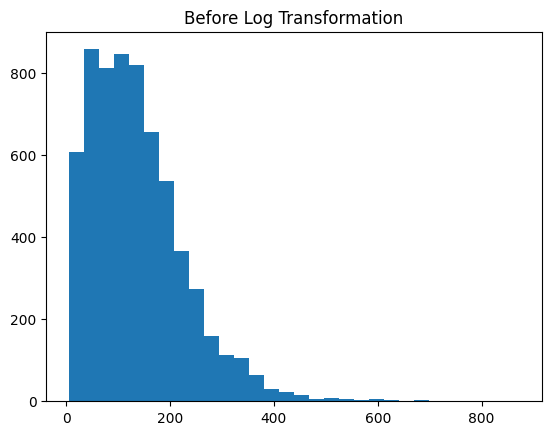

In [144]:
# Viewing the distribution of a feature 
plt.hist(imputed_data['urine_creatinine'], bins=30)
plt.title('Before Log Transformation')
plt.show()

The variable is right skewed

In [145]:
# Checking skewness for all numerical features to see if log-transformation is necessary
skewness = imputed_data[numerical_features].skew()
print(skewness)

age                         -0.246370
poverty_income_ratio        -0.013274
bmi                          1.149876
bp_systolic                  0.983928
bp_diastolic                 0.537461
serum_creatinine            15.612315
blood_urea_nitrogen          2.344599
albumin_serum               -0.419561
phosphorus                   0.534557
bicarbonate                 -0.000947
calcium                      0.094661
uric_acid                    0.606187
urine_creatinine             1.347108
urine_albumin               19.581444
albumin_creatinine_ratio    28.631765
egfr                        -0.179798
dtype: float64


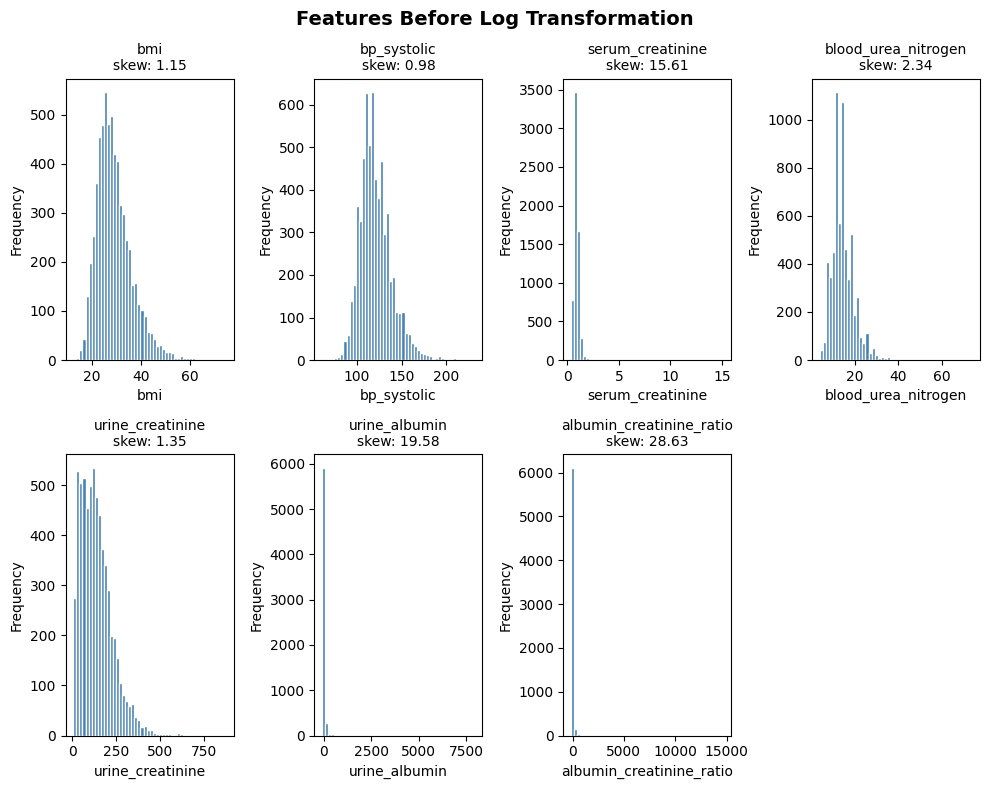

In [146]:
# Visualising numerical features before log transformation
skewed_features = ['bmi', 'bp_systolic', 'serum_creatinine', 'blood_urea_nitrogen', 'urine_creatinine', 'urine_albumin', 
                   'albumin_creatinine_ratio']

fig, axes = plt.subplots(2, 4, figsize=(10,8))
axes = axes.flatten()

for i, feature in enumerate(skewed_features):
    axes[i].hist(imputed_data[feature], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{feature}\nskew: {imputed_data[feature].skew():.2f}', fontsize=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Making the last plot hidden
axes[-1].set_visible(False)


plt.suptitle('Features Before Log Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


The laboratory biomarkers were highly positively skewed, with `alumin_creatinine_ratio` and `urine_albumin` having skeweness values of 28.6 and 19.58 respectively. To addess this, log-transformation will be applied to reduce skewness and reducing the impact of extreme values during modelling.




In [147]:
# Transforming variables using log1p as it helps in dealing with small values
log_imputed_data = imputed_data.copy()

for col in skewed_features:
    log_imputed_data[col] = np.log1p(log_imputed_data[col])


# Checking skewness after transformation
print(log_imputed_data[skewed_features].skew())

bmi                         0.340529
bp_systolic                 0.413406
serum_creatinine            3.058908
blood_urea_nitrogen         0.222690
urine_creatinine           -0.628684
urine_albumin               0.886438
albumin_creatinine_ratio    1.524768
dtype: float64


c:\Users\HALIMAT\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [148]:
# Checking for invalid values due to log1p error
for col in skewed_features:
    negative_values = (imputed_data[col] <0).sum()
    minimum_values = imputed_data[col].min()
    if negative_values > 0:
        print(f'{col}: {negative_values}  negative values, min = {minimum_values:.4f}') 

urine_albumin: 23  negative values, min = -85.6296
albumin_creatinine_ratio: 40  negative values, min = -169.6899


Following MICE imputation, `urine_albumin` (n=23) and `albumin_creatinine_ratio` (n=40) 
contained negative imputed values. These are clinically implausible as both features cannot be 
negative. These values were clipped to zero before log-transformation to ensure 
biological plausibility.

In [149]:
# Clipping columns with negative values to zero

cols_to_clip = ['urine_albumin', 'albumin_creatinine_ratio']

for col in cols_to_clip:
    imputed_data[col] = imputed_data[col].clip(lower=0)

In [150]:
# Checking there are no more negative values
for col in cols_to_clip:
    print(f'{col}: min = {imputed_data[col].min():.4f}, negative values = {(imputed_data[col] < 0).sum()}')

urine_albumin: min = 0.0000, negative values = 0
albumin_creatinine_ratio: min = 0.0000, negative values = 0


In [151]:
# Reapplying log-transformation

log_imputed_data = imputed_data.copy()

for col in skewed_features:
    log_imputed_data[col] = np.log1p(log_imputed_data[col])


# Checking skewness after transformation
print(log_imputed_data[skewed_features].skew())

bmi                         0.340529
bp_systolic                 0.413406
serum_creatinine            3.058908
blood_urea_nitrogen         0.222690
urine_creatinine           -0.628684
urine_albumin               0.861509
albumin_creatinine_ratio    1.435028
dtype: float64


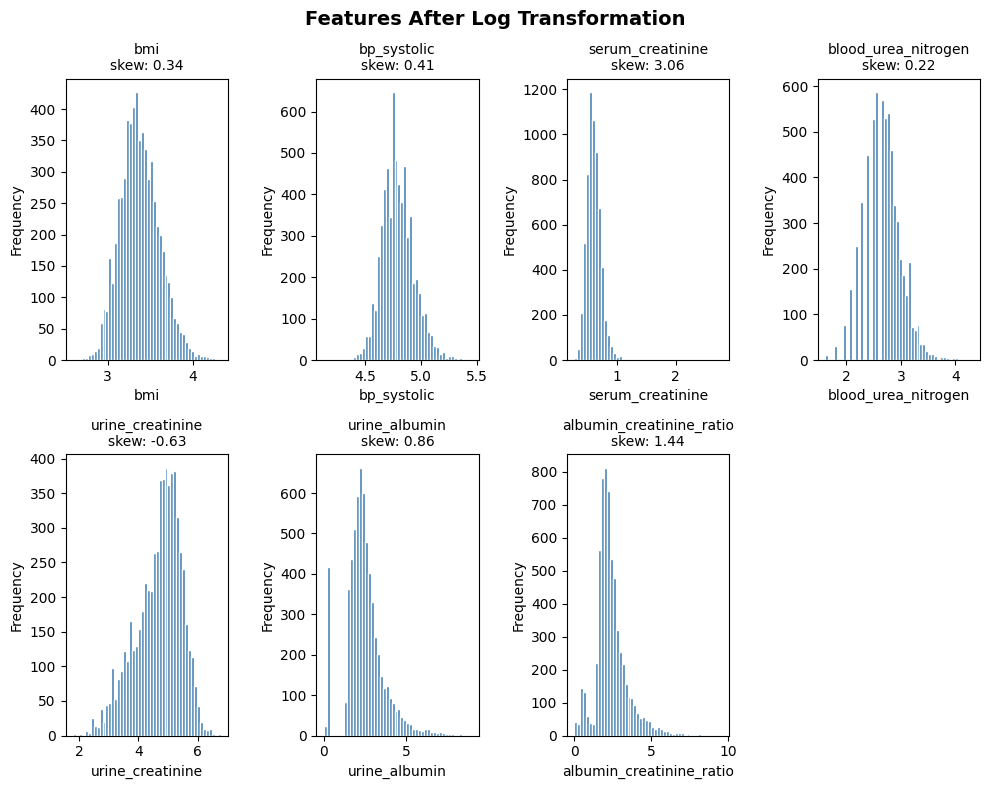

In [152]:
# Plotting the distribution after log transformation
fig, axes = plt.subplots(2, 4, figsize=(10,8))
axes = axes.flatten()

for i, feature in enumerate(skewed_features):
    axes[i].hist(log_imputed_data[feature], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{feature}\nskew: {log_imputed_data[feature].skew():.2f}', fontsize=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Making the last plot hidden
axes[-1].set_visible(False)


plt.suptitle('Features After Log Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Log-transformation reduced skewness across numerical features. Although there was still some skewness, it was left alone to avoid excessive manipulation of clinically meaningful values

#### Encoding

In [153]:
# Checking the unique values in education_level
log_imputed_data['education_level'].unique()

array([5.0, 3.0, 4.0, 2.0, 1.0], dtype=object)

In [154]:
log_imputed_data['ethnicity'].unique()

array(['Non-Hispanic Asian', 'Non-Hispanic White', 'Other Hispanic',
       'Mexican American', 'Non-Hispanic Black', 'Other/Multiracial'],
      dtype=object)

In [155]:
# diabetes_diagnosed and ever_smoked were coded as 1 and 2.  
# Mapping 2 to 0 (No) and keeping 1 as 1 (Yes) 
mapping = {1: 1, 2: 0}

log_imputed_data['diabetes_diagnosed'] = log_imputed_data['diabetes_diagnosed'].map(mapping)
log_imputed_data['ever_smoked'] = log_imputed_data['ever_smoked'].map(mapping)



In [156]:
# Defining categorical variables
categorical_features

['gender',
 'ethnicity',
 'education_level',
 'diabetes_diagnosed',
 'ever_smoked',
 'ckd_present']

`education_level` is treated as ordinal due to its inherent order.  One-hot was applied to `gender`, and `ethnicity`, while `diabetes_diagnosed`  and `ever_smoked` will be left as binary. 

In [157]:
# Encoding categorical features
encoded_data = pd.get_dummies(log_imputed_data,
                              columns= ['gender', 'ethnicity'],
                              drop_first=True
                             )

In [158]:
encoded_data.head()

,education_level,diabetes_diagnosed,ever_smoked,age,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr,ckd_present,gender_Male,ethnicity_Non-Hispanic Asian,ethnicity_Non-Hispanic Black,ethnicity_Non-Hispanic White,ethnicity_Other Hispanic,ethnicity_Other/Multiracial
0,5.0,0,1,43.0,5.00,3.332205,4.912655,98.0,0.587787,2.484907,4.3,3.7,24.0,9.6,5.1,4.919981,3.183041,2.890372,112.61,0,True,True,False,False,False,False
1,5.0,0,1,66.0,5.00,3.540959,4.804021,84.0,0.582216,3.218876,3.9,3.2,25.0,9.4,8.5,4.174387,1.658228,2.033398,97.98,0,True,False,False,True,False,False
2,3.0,1,0,44.0,1.41,3.424263,4.718499,79.0,0.494696,2.397895,3.7,3.8,25.0,9.4,4.4,5.062595,2.597491,2.188296,111.69,0,False,False,False,False,True,False
3,4.0,0,1,34.0,1.33,3.440418,4.709530,72.0,0.598837,2.890372,4.3,3.3,21.0,9.5,6.0,4.736198,1.722767,1.623341,118.21,0,True,False,False,False,False,False
4,5.0,0,0,68.0,1.32,3.775057,4.969813,76.0,0.565314,2.772589,3.7,3.5,24.0,9.3,6.2,3.178054,1.935860,3.287655,85.30,1,False,False,False,True,False,False


In [159]:
# Convert float to int

columns_to_integer = ['age', 'diabetes_diagnosed', 'education_level', 'ever_smoked']
encoded_data[columns_to_integer] = encoded_data[columns_to_integer].astype(int)

In [160]:
# Saving the preproceesed data to a csv file
encoded_data.to_csv('nhanes_ckd_processed_data.csv', index=False)

encoded_data = pd.read_csv('nhanes_ckd_processed_data.csv')
encoded_data.head()

,education_level,diabetes_diagnosed,ever_smoked,age,poverty_income_ratio,bmi,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,egfr,ckd_present,gender_Male,ethnicity_Non-Hispanic Asian,ethnicity_Non-Hispanic Black,ethnicity_Non-Hispanic White,ethnicity_Other Hispanic,ethnicity_Other/Multiracial
0,5,0,1,43,5.00,3.332205,4.912655,98.0,0.587787,2.484907,4.3,3.7,24.0,9.6,5.1,4.919981,3.183041,2.890372,112.61,0,True,True,False,False,False,False
1,5,0,1,66,5.00,3.540959,4.804021,84.0,0.582216,3.218876,3.9,3.2,25.0,9.4,8.5,4.174387,1.658228,2.033398,97.98,0,True,False,False,True,False,False
2,3,1,0,44,1.41,3.424263,4.718499,79.0,0.494696,2.397895,3.7,3.8,25.0,9.4,4.4,5.062595,2.597491,2.188296,111.69,0,False,False,False,False,True,False
3,4,0,1,34,1.33,3.440418,4.709530,72.0,0.598837,2.890372,4.3,3.3,21.0,9.5,6.0,4.736198,1.722767,1.623341,118.21,0,True,False,False,False,False,False
4,5,0,0,68,1.32,3.775057,4.969813,76.0,0.565314,2.772589,3.7,3.5,24.0,9.3,6.2,3.178054,1.935860,3.287655,85.30,1,False,False,False,True,False,False


## Model Development

This is a binary classification task, with the target variable representing the presence 
or absence of CKD.

**Baseline Model:** 
Logistic Regression was selected as the baseline model because it outputs predicted probabilities. These probabilities support clinical interpretation by enabling the identification of individuals at different levels of risk. LR also provides direct coefficient interpretation which makes it easier to understand how each predictor influences CKD risk. It also requires minimal computational resources and is well suited for tabular data.

**Advanced Models:** 
1. **Random Forest**: This is a tree-based ensemble method that is robust to noisy data and can handle multicollinearity more effectively than LR. It does not require feature scaling for model performance. 
2. **XGBoost:** This is a gradient boosting algorithm capable of capturing complex non-linear relationships and feature interactions. It is widely used in medical diagnosis tasks due to its strong performance on structured datasets.

**Initial Model Check**

Initial modelling was performed on the full feature set without a pipeline to assess 
baseline behaviour and evaluate the impact of including direct diagnostic variables. 
This produced implausibly high accuracy (>99%), confirming that features such as 
`serum_creatinine`, `urine_albumin`, and `albumin_creatinine_ratio` caused data 
leakage. These features were subsequently removed to perform main modelling.

**Final Modelling Pipeline**

Feature scaling was applied exclusively to Logistic Regression, as tree-based models 
(Random Forest, XGBoost) are invariant to feature scale. To prevent data leakage, 
StandardScaler was fitted on the training set only and applied to the test set.

A pipeline was implemented 
to ensure StandardScaler was fitted on training data only and consistently applied 
across cross-validation folds. This prevents data leakage and ensures reproducibility.

The term "baseline" is used in two distinct ways in this section. Logistic Regression is the baseline model. Random Forest and XGBoost are the advanced models. All three are also initially trained with default parameters before tuning — these runs are referred to as "baseline performance" to distinguish pre-tuning from post-tuning results.

#### Initial Modelling

In [161]:
# Making a copy of the preprocessed data
modelling_data = encoded_data.copy()

In [162]:
# Drop egfr, the variable used to define the target
modelling_data = modelling_data.drop(columns=['egfr'])

In [163]:
# Separating the features and the target
X = modelling_data.drop(columns=['ckd_present'])
y = modelling_data['ckd_present']

# Checking the shape of X and y
print(X.shape)
print(y.shape)

print(y.value_counts())

(6326, 24)
(6326,)
ckd_present
0    3592
1    2734
Name: count, dtype: int64


In [164]:
# Splitting the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


In [165]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

ckd_present
0    0.567787
1    0.432213
Name: proportion, dtype: float64
ckd_present
0    0.56793
1    0.43207
Name: proportion, dtype: float64


In [166]:
# Standardisation using StandardScaler()
# Fitting standardscaler on the training data to avoid leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [167]:
# Logistic regression model with default parameters
baseline_lr_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [168]:
# Quick check on the test set
baseline_lr_preds = baseline_lr_model.predict(X_test_scaled)

# Predicting probabilities and calculating AUC
baseline_pred_proba = baseline_lr_model.predict_proba(X_test_scaled)[:, 1]
#baseline_lr_auc = roc_auc_score(y_test, baseline_pred_proba)


print('-' * 50)
print('Logistic Regression Initial Evaluation Results')
print(f'ROC-AUC: {roc_auc_score(y_test, baseline_pred_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_lr_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_lr_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_lr_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_lr_preds):.3f}')

--------------------------------------------------
Logistic Regression Initial Evaluation Results
ROC-AUC: 0.958
Recall: 0.870
Precision : 0.905
F1-Score: 0.887
Accuracy: 0.904


In [169]:
# Testing the baseline random forest

# Training Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

baseline_rf_preds = rf_model.predict(X_test)

# Predicting probabilities and calculating AUC
rf_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('-' * 50)
print('Random Forest Initial Evaluation Results')
print(f'ROC-AUC: {roc_auc_score(y_test, rf_test_pred_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_rf_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_rf_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_rf_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_rf_preds):.3f}')

--------------------------------------------------
Random Forest Initial Evaluation Results
ROC-AUC: 0.992
Recall: 0.934
Precision : 0.970
F1-Score: 0.952
Accuracy: 0.959


In [170]:
# Training Xgboost model
xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

baseline_xgb_preds = xgb_model.predict(X_test)

# Predicting probabilities and calculating AUC
xgb_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print('-' * 50)
print('XGBoost Initial Evaluation Results')
print(f'ROC-AUC: {roc_auc_score(y_test, xgb_test_pred_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_xgb_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_xgb_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_xgb_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_xgb_preds):.3f}')


--------------------------------------------------
XGBoost Initial Evaluation Results
ROC-AUC: 0.999
Recall: 0.991
Precision : 0.982
F1-Score: 0.986
Accuracy: 0.988


In [171]:
# Assessing feature importance for RF model to see key predictors of CKD
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                         Feature  Importance
8               serum_creatinine    0.259712
3                            age    0.203806
17      albumin_creatinine_ratio    0.117422
16                 urine_albumin    0.057114
9            blood_urea_nitrogen    0.050262
18                   gender_Male    0.041685
6                    bp_systolic    0.037674
15              urine_creatinine    0.028060
14                     uric_acid    0.027535
5                            bmi    0.024565
10                 albumin_serum    0.023525
7                   bp_diastolic    0.023484
11                    phosphorus    0.020310
4           poverty_income_ratio    0.019221
13                       calcium    0.016556
12                   bicarbonate    0.015036
0                education_level    0.008492
2                    ever_smoked    0.006297
21  ethnicity_Non-Hispanic White    0.005488
1             diabetes_diagnosed    0.004509
20  ethnicity_Non-Hispanic Black    0.002699
19  ethnic

Initial models produced implausibly high performance — Logistic Regression achieved a 
Recall of **0.870** and ROC-AUC of **0.958**, while XGBoost reached a Recall of **0.991** 
and ROC-AUC of **0.999**. This raised concerns about data leakage.

Feature importance analysis confirmed that the models were the top predictor 
variables (`serum_creatinine`, `urine_albumin`, `albumin_creatinine_ratio`, 
`blood_urea_nitrogen`, `urine_creatinine`). These variables are directly used by clinicians in 
CKD diagnosis. Including these features reduces the model to a system that replicates 
the clinical diagnostic calculation rather than learning meaningful predictive patterns.

According to a systematic review, including variables used in clinical diagnoses forces the model to rely on deterministic relationships, effectively reducing its decision-making process to a rule-based system. This transforms a machine learning model into a 'linear decsion flow-chart' which results in consistently inflated performance. The review reported multiple studies where accuracy , specificity, and ROC-AUC were never below 98% where such variables were included (Sanmarchi et al., 2023). 

These variables were therefore excluded. The resulting model serves as a diagnostic 
support tool that identifies individuals at risk of CKD using demographic, lifestyle, 
and indirect biomarker features. It is for targeting early-stage detection where primary 
diagnostic markers may not yet have crossed the definitive clinical threshold.


#### Main Modelling Pipeline with Default Parameters  

Model development using non-diagnostic features (Baseline models)

In [172]:
# Dropping diagnostic variables
modelling_data = modelling_data.drop(columns=['serum_creatinine', 
                                              'urine_creatinine', 
                                              'urine_albumin',
                                              'albumin_creatinine_ratio',
                                              'blood_urea_nitrogen',])

In [173]:
modelling_data.columns.to_list()

['education_level',
 'diabetes_diagnosed',
 'ever_smoked',
 'age',
 'poverty_income_ratio',
 'bmi',
 'bp_systolic',
 'bp_diastolic',
 'albumin_serum',
 'phosphorus',
 'bicarbonate',
 'calcium',
 'uric_acid',
 'ckd_present',
 'gender_Male',
 'ethnicity_Non-Hispanic Asian',
 'ethnicity_Non-Hispanic Black',
 'ethnicity_Non-Hispanic White',
 'ethnicity_Other Hispanic',
 'ethnicity_Other/Multiracial']

In [174]:
# Separating the features and the target
X = modelling_data.drop(columns=['ckd_present'])
y = modelling_data['ckd_present']

# Checking the shape of X and y
print(X.shape)
print(y.shape)

print(y.value_counts())

(6326, 19)
(6326,)
ckd_present
0    3592
1    2734
Name: count, dtype: int64


In [175]:
# Splitting the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [176]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

ckd_present
0    0.567787
1    0.432213
Name: proportion, dtype: float64
ckd_present
0    0.56793
1    0.43207
Name: proportion, dtype: float64


In [177]:
# Baseline model
# Defining LR pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_lr_cv_recall = cross_val_score(lr_pipeline, X_train, y_train, cv=cv, scoring='recall')

print('-' * 50)
print('Logistic Regression CV Recall Score:', baseline_lr_cv_recall.mean())

# Fitting the pipeline
lr_pipeline.fit(X_train, y_train)

# Predictions on test set
baseline_lr_preds = lr_pipeline.predict(X_test)
baseline_lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]


print('-' * 50)
print('Logistic Regression Baseline Results')
print(f'ROC-AUC: {roc_auc_score(y_test, baseline_lr_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_lr_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_lr_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_lr_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_lr_preds):.3f}')


--------------------------------------------------
Logistic Regression CV Recall Score: 0.7416570013479201
--------------------------------------------------
Logistic Regression Baseline Results
ROC-AUC: 0.833
Recall: 0.717
Precision : 0.737
F1-Score: 0.727
Accuracy: 0.767


Cross-validation recall **(0.742)** was slightly higher than the test recall **(0.717)**. This suggest slight overfitting but good generalisation.

In [178]:
# Defining RF pipeline
# Scaling is not included in the pipeline because RF is generally non sensitive to outliers
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42, n_estimators=100))
])

# Cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_rf_cv_recall = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='recall')

print('-' * 50)
print('RF CV Recall Score:', baseline_rf_cv_recall.mean())

# Fitting the pipeline
rf_pipeline.fit(X_train, y_train)

# Predictions on test set
baseline_rf_preds = rf_pipeline.predict(X_test)
baseline_rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]


print('-' * 50)
print('Random Forest Baseline Evaluation Results')
print(f'ROC-AUC: {roc_auc_score(y_test, baseline_rf_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_rf_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_rf_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_rf_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_rf_preds):.3f}')


--------------------------------------------------
RF CV Recall Score: 0.7073571361399329
--------------------------------------------------
Random Forest Baseline Evaluation Results
ROC-AUC: 0.830
Recall: 0.698
Precision : 0.726
F1-Score: 0.712
Accuracy: 0.756


In [179]:
# XGB pipeline
xgb_pipeline = Pipeline([
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# Cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_xgb_cv_recall = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='recall')

print('-' * 50)
print('XGB CV Recall Score:', baseline_xgb_cv_recall.mean())

# Fitting the pipeline
xgb_pipeline.fit(X_train, y_train)

# Predictions on test set
baseline_xgb_preds = xgb_pipeline.predict(X_test)
baseline_xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]


print('-' * 50)
print('Random Forest Baseline Evaluation Results')
print(f'ROC-AUC: {roc_auc_score(y_test, baseline_xgb_proba):.3f}')
print(f'Recall: {recall_score(y_test, baseline_xgb_preds):.3f}')
print(f'Precision : {precision_score(y_test, baseline_xgb_preds):.3f}')
print(f'F1-Score: {f1_score(y_test, baseline_xgb_preds):.3f}')
print(f'Accuracy: {accuracy_score(y_test, baseline_xgb_preds):.3f}')


--------------------------------------------------
XGB CV Recall Score: 0.6703279938977879
--------------------------------------------------
Random Forest Baseline Evaluation Results
ROC-AUC: 0.801
Recall: 0.680
Precision : 0.714
F1-Score: 0.697
Accuracy: 0.744


In [180]:
# Cresting a dataframe for the results
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Recall': [0.717, 0.698, 0.680],
    'Precision': [0.737, 0.726, 0.714],
    'ROC-AUC': [0.833, 0.830,0.801 ],
    'F1-score': [0.727, 0.712, 0.697],
    'Accuracy': [0.767, 0.756, 0.744],
}

# Creating a dataframe
baseline_results = pd.DataFrame(results)

# baseline_results.set_index('Model', inplace=True)

print(baseline_results)

                 Model  Recall  Precision  ROC-AUC  F1-score  Accuracy
0  Logistic Regression   0.717      0.737    0.833     0.727     0.767
1        Random Forest   0.698      0.726    0.830     0.712     0.756
2              XGBoost   0.680      0.714    0.801     0.697     0.744


Logistic Regression achieved the strongest baseline performance with a Recall of **0.717** 
and ROC-AUC of **0.833**, demonstrating good sensitivity to CKD cases and strong class 
separation. Random Forest performed comparably (Recall- **0.698**, ROC-AUC - **0.830**), 
while XGBoost produced the lowest baseline scores (Recall - **0.680**, ROC-AUC - **0.801**).

#### Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV with k-fold cross-validation on 
the training set to optimise model performance and reduce overfitting. All three models 
were tuned to ensure fair comparison. Final model performance was evaluated on the held-out 
test set. The hyperparameters searched are summarised in the table below:

| Model | Hyperparameter        | Values Tested                          |
|------|-----------------------|----------------------------------------|
| LR   | C                     | [0.01, 0.1, 1, 10, 100]                 |
| RF   | n_estimators          | [50, 100, 200, 500]                    |
| RF   | max_depth             | [None, 10, 20, 30]                     |
| RF   | bootstrap             | [True, False]                          |
| RF   | min_samples_split     | [2, 5]                                 |
| XGB  | n_estimators          | [100, 200, 500]                        |
| XGB  | max_depth             | [3, 5]                                 |
| XGB  | learning_rate         | [0.05, 0.1]                            |
| XGB  | subsample             | [0.8, 1.0]                             |



In [181]:
# Tuning LR Model
lr_params = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
print('Best Logistic Regression params: ', lr_grid.best_params_)
print('LR CV Recall: ', lr_grid.best_score_) 


Best Logistic Regression params:  {'model__C': 0.1}
LR CV Recall:  0.736166055400562


In [182]:
# Tuning Rf model
rf_params = {
    'model__n_estimators': [50, 100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__bootstrap': [True, False],
    'model__min_samples_split': [2,5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print('Best Random Forest params:', rf_grid.best_params_)
print('RF CV Recall: ', rf_grid.best_score_)

Best Random Forest params: {'model__bootstrap': False, 'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 500}
RF CV Recall:  0.7329717981672467


In [183]:
# Tuning XGB model
xgb_params = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth':[3, 5],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print('Best Xgboost params:', xgb_grid.best_params_)
print('XGB CV Recall: ', xgb_grid.best_score_)


Best Xgboost params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
XGB CV Recall:  0.722905238080311


In [184]:
# Evaluating all Models
lr_pred = best_lr.predict(X_test)
lr_proba = best_lr.predict_proba(X_test)[:, 1]

In [185]:
# Evaluating All model
rf_pred = best_rf.predict(X_test)
rf_proba = best_rf.predict_proba(X_test)[:, 1]

In [186]:
# Evaluating All model
xgb_pred = best_xgb.predict(X_test)
xgb_proba = best_xgb.predict_proba(X_test)[:, 1]

In [187]:
# Storing results in a dataframe
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, xgb_proba)
    ],
    'F1-score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
     'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
     ]
})

print(model_results)

                 Model    Recall  Precision   ROC-AUC  F1-score  Accuracy
0  Logistic Regression  0.716636   0.736842  0.832555  0.726599  0.766983
1        Random Forest  0.718464   0.721101  0.831647  0.719780  0.758294
2              XGBoost  0.692870   0.734496  0.832045  0.713076  0.759084


In [188]:
model_results = model_results.round(3)
print(model_results)

                 Model  Recall  Precision  ROC-AUC  F1-score  Accuracy
0  Logistic Regression   0.717      0.737    0.833     0.727     0.767
1        Random Forest   0.718      0.721    0.832     0.720     0.758
2              XGBoost   0.693      0.734    0.832     0.713     0.759


In [189]:
# Saving models results to a csv file 
model_results.to_csv('CKD Model Results.csv', index=False)

Following hyperparameter tuning, Logistic Regression showed no change in performance, 
suggesting it reached near-optimal performance with default parameters.

Both advanced models improved after tuning. Random Forest achieved a Recall of **0.718** 
and ROC-AUC of **0.832**, while XGBoost improved to a Recall of **0.693** and ROC-AUC 
of **0.832**. Despite these gains, Logistic Regression retained the strongest overall 
performance across all metrics.

### Baseline Models Performances - Default Parameters

| Model | Recall | Precision | ROC-AUC | F1-Score | Accuracy |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.717 | 0.737 | 0.833 | 0.727 | 0.767 |
| **Random Forest** | 0.698 | 0.726 | 0.830 | 0.712 | 0.756 |
| **XGBoost** | 0.680 | 0.714 | 0.801 | 0.697 | 0.744 |

### Tuned Models Performances

| Model | Recall | Precision | ROC-AUC | F1-Score | Accuracy |
|---|---|---|---|---|---|
| **Logistic Regression** | 0.717 | 0.737 | 0.833 | 0.727 | 0.767 |
| **Random Forest** | 0.718 | 0.721 | 0.832 | 0.720 | 0.758 |
| **XGBoost** | 0.693 | 0.734 | 0.832 | 0.713 | 0.759 |

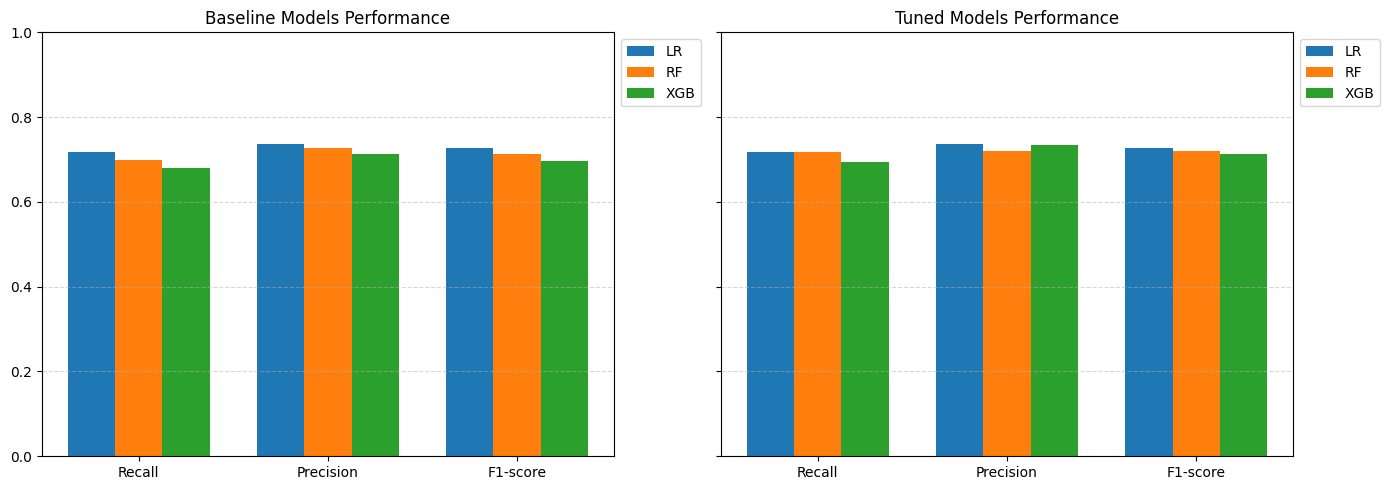

In [190]:
# Plotting bar charts to compare the baseline models' peformance
metrics = ["Recall", "Precision", "F1-score"]
x = np.arange(len(metrics))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 
lr_base = baseline_results[baseline_results["Model"]=="Logistic Regression"][metrics].values[0]
rf_base = baseline_results[baseline_results["Model"]=="Random Forest"][metrics].values[0]
xgb_base = baseline_results[baseline_results["Model"]=="XGBoost"][metrics].values[0]

axes[0].bar(x - width, lr_base, width, label="LR")
axes[0].bar(x, rf_base, width, label="RF")
axes[0].bar(x + width, xgb_base, width, label="XGB")

axes[0].set_title("Baseline Models Performance")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1))

# Tuned models performance
lr_tuned = model_results[model_results["Model"]=="Logistic Regression"][metrics].values[0]
rf_tuned = model_results[model_results["Model"]=="Random Forest"][metrics].values[0]
xgb_tuned = model_results[model_results["Model"]=="XGBoost"][metrics].values[0]

axes[1].bar(x - width, lr_tuned, width, label="LR")
axes[1].bar(x, rf_tuned, width, label="RF")
axes[1].bar(x + width, xgb_tuned, width, label="XGB")

axes[1].set_title("Tuned Models Performance")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

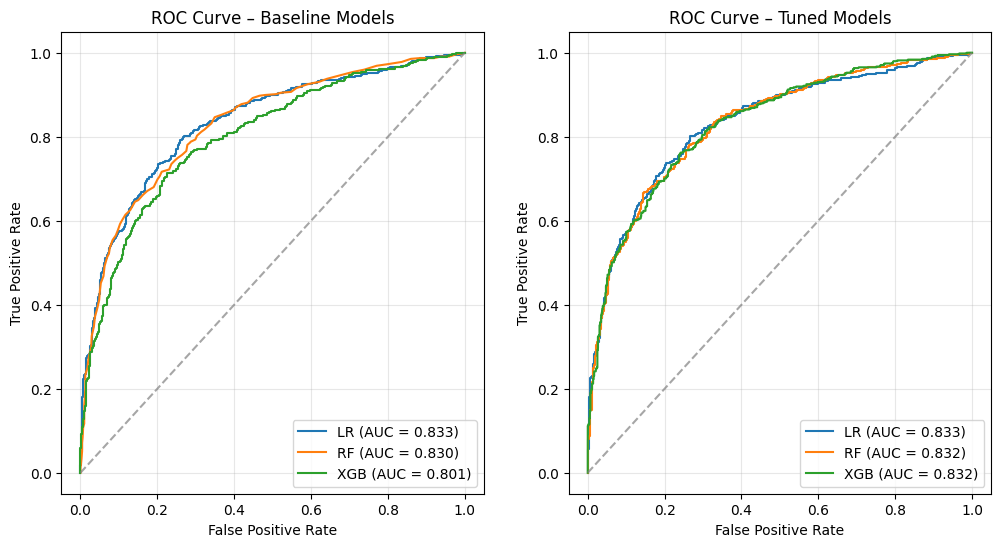

In [191]:
# Creatting side-by-side ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting for left plot (baseline)
ax = axes[0]

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, baseline_lr_proba)
auc_lr = roc_auc_score(y_test, baseline_lr_proba)
ax.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, baseline_rf_proba)
auc_rf = roc_auc_score(y_test, baseline_rf_proba)
ax.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, baseline_xgb_proba)
auc_xgb = roc_auc_score(y_test, baseline_xgb_proba)
ax.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc_xgb:.3f})")

# Reference line
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.7)

# Formatting
ax.set_title("ROC Curve – Baseline Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Plotting for the right plot (Tuned models)
ax = axes[1]

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = roc_auc_score(y_test, lr_proba)
ax.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = roc_auc_score(y_test, rf_proba)
ax.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})")

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
auc_xgb = roc_auc_score(y_test, xgb_proba)
ax.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc_xgb:.3f})")

# Reference line
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.7)

# Formatting
ax.set_title("ROC Curve – Tuned Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)


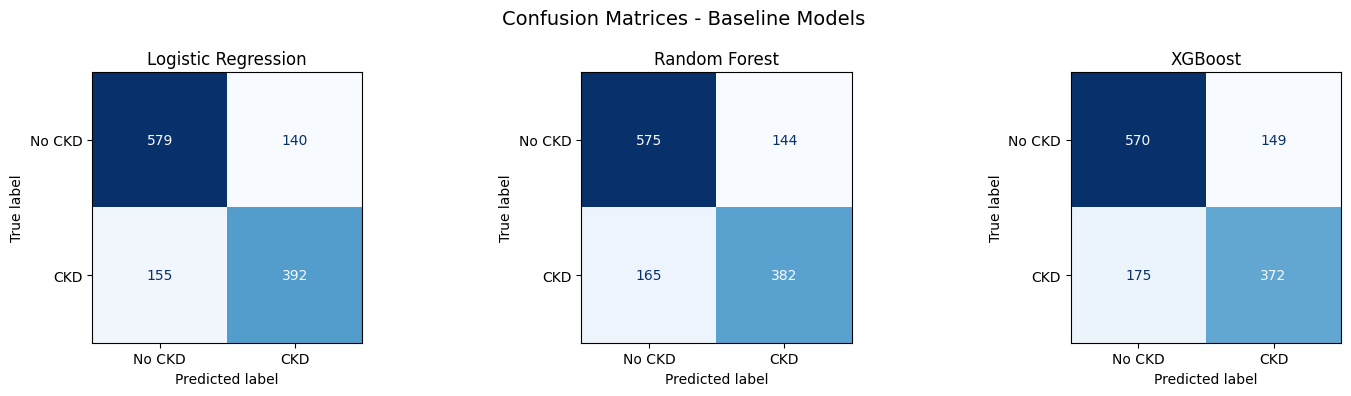

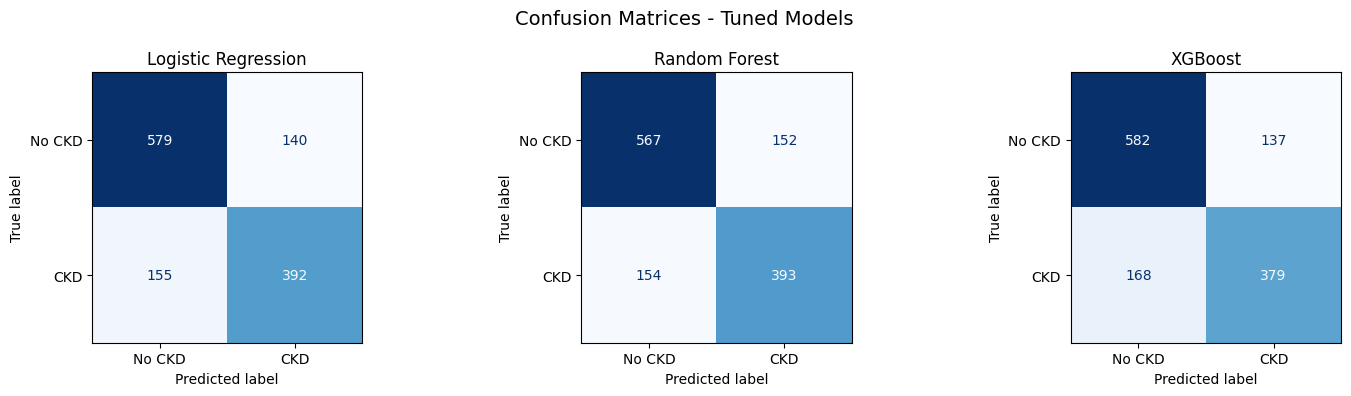

In [192]:
# Confusion matrices for baseline models and tuned 

# Plotting confusion matrices to compare baseline models predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", baseline_lr_preds),
    ("Random Forest", baseline_rf_preds),
    ("XGBoost", baseline_xgb_preds)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No CKD", "CKD"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)
    
fig.suptitle("Confusion Matrices - Baseline Models", fontsize=14)
plt.tight_layout()
plt.show()

# Confusion matrices for tuned models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No CKD", "CKD"])
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(name)
    
fig.suptitle("Confusion Matrices - Tuned Models", fontsize=14)
plt.tight_layout()
plt.show()



At baseline, LR demonstrated the highest sensitivity, producing fewer false negatives (**155**) than RF (**165**) and XGBoost (**175**). Given the clinical priority of minimising missed CKD cases, this suggests the linear model 
effectively captured the predictive signal present in the retained feature set.

Following tuning, LR remained unchanged while Random Forest reduced 
false negatives to **154** and XGBoost to **168**. Despite these improvements, 
performance differences across all three models remained marginal.

**Final Model Selection**

LR was selected as the final model based on its consistent performance 
across all evaluation metrics, achieving the highest Recall (**0.717**) and ROC-AUC 
(**0.833**) among the three models. In a clinical context where minimising missed CKD 
cases is the priority, Recall was the primary selection criterion.

Beyond performance, LR offers inherent interpretability through its coefficients, making 
it more suitable for clinical decision support than complex ensemble methods.

**Threshold Analysis**

The default classification threshold of 0.5 was adjusted to optimise the trade-off  between Recall and Precision. Thresholds from 0.1 to 1.0 were evaluated on the selected 
LR model.

As expected, lower thresholds increased Recall at the cost of Precision. A threshold of 
**0.4** was selected as it maximised the F1-score (**0.741**) while meaningfully improving 
Recall from **0.717** to **0.806**. At the extreme of 0.1, Recall reached **0.996** but 
the model predicted CKD for virtually all participants — clinically unacceptable.

Lowering the threshold from 0.5 to 0.4 reduced false negatives from **155** to **106**, 
meaning fewer CKD cases were missed. This was accompanied by an increase in false 
positives, resulting in more individuals incorrectly flagged as CKD-positive. In a 
clinical screening context where early detection is the priority, this trade-off is 
considered acceptable — unnecessary follow-up testing is preferable to missed diagnoses.

In [193]:
# Defining thresholds
thresholds = np.arange(0.1, 1.01, 0.1)

# Empty dataframe for storing results
results = []

for t in thresholds:
    preds = (lr_proba >= t).astype(int)
    
    results.append({
        "Threshold": t,
        "Recall": recall_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
        "Accuracy": accuracy_score(y_test, preds)
    })

threshold_df = pd.DataFrame(results)
threshold_df = threshold_df.round(3)

print(threshold_df)

   Threshold  Recall  Precision  F1-score  Accuracy
0        0.1   0.949      0.495     0.651     0.560
1        0.2   0.899      0.578     0.704     0.673
2        0.3   0.850      0.632     0.725     0.721
3        0.4   0.806      0.685     0.741     0.756
4        0.5   0.717      0.737     0.727     0.767
5        0.6   0.623      0.791     0.697     0.766
6        0.7   0.484      0.860     0.620     0.743
7        0.8   0.272      0.931     0.421     0.677
8        0.9   0.059      0.941     0.110     0.592
9        1.0   0.000      0.000     0.000     0.568


c:\Users\HALIMAT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


A threshold of **0.4** was selected as it maximised the F1-score (**0.741**) while 
meaningfully improving Recall from **0.717** to **0.806** and a precision of **0.685**. This means, of all 
individuals flagged as CKD-positive, about **69%** were true positives. At the extreme of 0.1, Recall reached **0.949** but the model 
predicted CKD for virtually all participants — clinically unacceptable.

**Final Threshold Optimization Results for Logistic Regression**

| Threshold | Recall | Precision | F1-score | Accuracy |
|----------:|-------:|----------:|---------:|---------:|
| 0.1 | 0.949 | 0.495 | 0.651 | 0.560 |
| 0.2 | 0.899 | 0.578 | 0.704 | 0.673 |
| 0.3 | 0.850 | 0.632 | 0.725 | 0.721 |
| 0.4 | 0.806 | 0.685 | 0.741 | 0.756 |
| 0.5 | 0.717 | 0.737 | 0.727 | 0.767 |
| 0.6 | 0.623 | 0.791 | 0.697 | 0.766 |
| 0.7 | 0.484 | 0.860 | 0.620 | 0.743 |
| 0.8 | 0.272 | 0.931 | 0.421 | 0.677 |
| 0.9 | 0.059 | 0.941 | 0.110 | 0.592 |
| 1.0 | 0.000 | 0.000 | 0.000 | 0.568 |

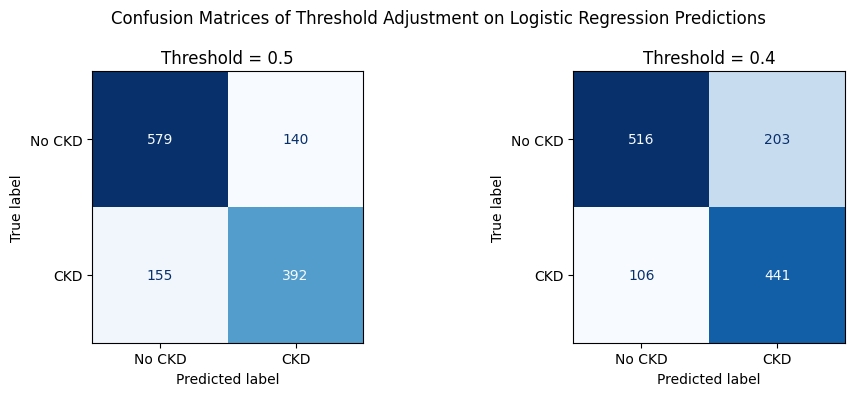

In [194]:
# Plotting confusiom matrix to compare between thresholds 0.5 and 0.4 
# predictions
lr_pred_05 = (lr_proba >= 0.5).astype(int)
lr_pred_04 = (lr_proba >= 0.4).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 0.5 threshold
cm_05 = confusion_matrix(y_test, lr_pred_05)
disp_05 = ConfusionMatrixDisplay(cm_05, display_labels=["No CKD", "CKD"])
disp_05.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Threshold = 0.5")

# 0.4 threshold
cm_04 = confusion_matrix(y_test, lr_pred_04)
disp_04 = ConfusionMatrixDisplay(cm_04, display_labels=["No CKD", "CKD"])
disp_04.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Threshold = 0.4")

fig.suptitle("Confusion Matrices of Threshold Adjustment on Logistic Regression Predictions")

plt.tight_layout()
plt.show()

Lowering the threshold from 0.5 to 0.4 reduced false negatives from **155** to 
**106**, meaning fewer CKD cases were missed. This was accompanied by an increase 
in false positives, resulting in more individuals incorrectly flagged as CKD-positive. 
In a clinical diagnostic context where early detection is the priority, this trade-off 
is considered acceptable. Unnecessary follow-up testing, although has its own problems, a missed diagnosis is costlier.

## Explainable Analysis

SHAP (SHapley Additive exPlanations) was used to interpret the logistic regression model and explain its predictions in a clinically meaningful way. LinearExplainer was used as it was specifically designed for linear models. It computes exact SHAP values efficiently by exploiting the linear relationship between features and model output.

In [195]:
X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

In [196]:
X_test_f.dtypes

education_level                 float64
diabetes_diagnosed              float64
ever_smoked                     float64
age                             float64
poverty_income_ratio            float64
bmi                             float64
bp_systolic                     float64
bp_diastolic                    float64
albumin_serum                   float64
phosphorus                      float64
bicarbonate                     float64
calcium                         float64
uric_acid                       float64
gender_Male                     float64
ethnicity_Non-Hispanic Asian    float64
ethnicity_Non-Hispanic Black    float64
ethnicity_Non-Hispanic White    float64
ethnicity_Other Hispanic        float64
ethnicity_Other/Multiracial     float64
dtype: object

In [197]:
# Extracting logistic regression from the pipeline
model = best_lr.named_steps['model']   

X_train_t = best_lr[:-1].transform(X_train)
X_test_t = best_lr[:-1].transform(X_test)


X_train_t = pd.DataFrame(X_train_t, columns=X_train.columns)
X_test_t = pd.DataFrame(X_test_t, columns=X_test.columns)


In [198]:
# This function renamed columns just for the sake of making the plots readable
def clean_name(col):
    return (
        col.replace('education_level', 'Education level')
           .replace('diabetes_diagnosed', 'Diabetes')
           .replace('ever_smoked', 'Ever Smoked')
           .replace('poverty_income_ratio', 'Poverty Income Ratio')
           .replace('bmi', 'BMI')
           .replace('bp_systolic', 'Systolic BP')
           .replace('bp_diastolic', 'Diastolic BP')
           .replace('phosphorus', 'Phosphorus')
           .replace('bicarbonate', 'Bicarbonate')
           .replace('calcium', 'Calcium')
           .replace('uric_acid', 'Uric Acid')
           .replace('gender_Male', 'Gender')
           .replace('ethnicity_Non-Hispanic Asian', 'Ethnicity: Non-Hispanic Asian')
           .replace('ethnicity_Non-Hispanic Black', 'Ethnicity: Non-Hispanic Black')
           .replace('ethnicity_Non-Hispanic White', 'Ethnicity: Non-Hispanic White')
           .replace('ethnicity_Other Hispanic', 'Ethnicity: Hispanic')
           .replace('ethnicity_Other/Multiracial', 'Ethnicity: Multiracial')
            
           .title()
    )

X_test_t.columns = [clean_name(c) for c in X_test.columns]
X_train_t.columns = X_test_t.columns


In [199]:
# Defining the explainer
explainer = shap.LinearExplainer(model, X_train_t)
shap_values = explainer(X_test_t)

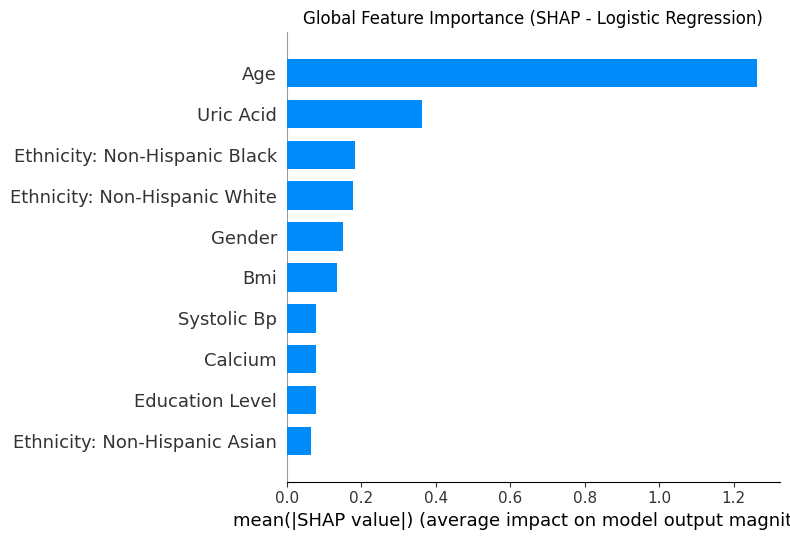

In [200]:
shap.summary_plot(
    shap_values,
    X_test_t,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Global Feature Importance (SHAP - Logistic Regression)")
plt.tight_layout()
plt.show()

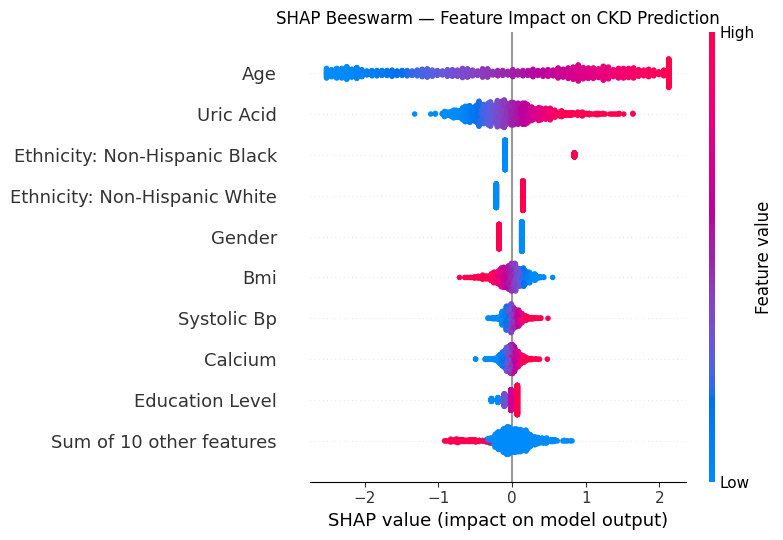

In [201]:
# Plotting beeswarm: feature impact  
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.title("SHAP Beeswarm — Feature Impact on CKD Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()

The beeswarm plot shows each feature's impact on individual CKD predictions.The red indicates high feature values and blue indicates low values. Age was the strongest predictor. High age pushed predictions towards CKD, consistent with age-related decline in kidney  function. Uric acid the next highest predictor. Non-Hispanic Black individuals showed a positive SHAP contribution. This is consistent with documented higher CKD prevalence in this group. Systolic BP showed a similar pattern. Calcium showed an inverse relationship, where lower values increased risk, reflecting impaired calcium regulation in declining renal function. Overall, the model's top predictors are clinically plausible and align with established CKD risk factors, supporting its utility as an early detection tool.


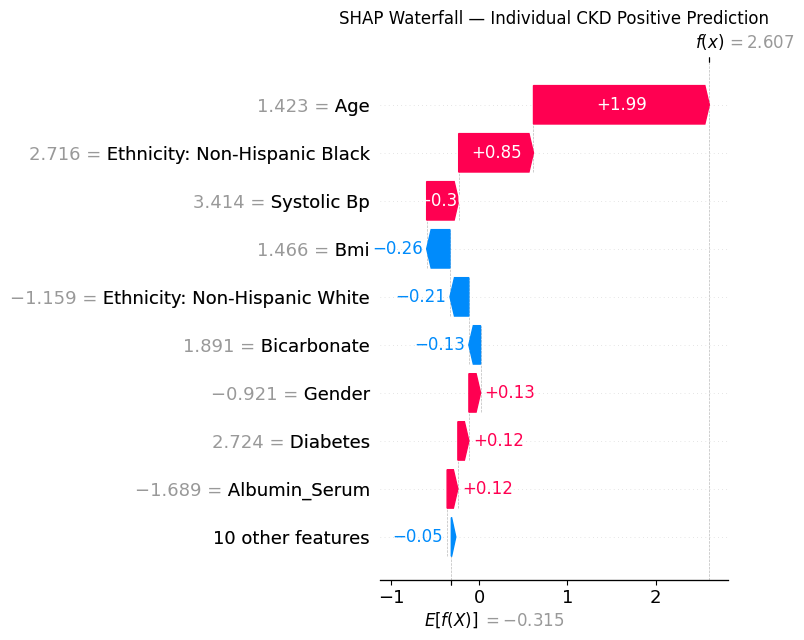

In [202]:

# Plotting waterfall for single patient 
pos_idx = np.where(y_test.values == 1)[0][0]
shap.plots.waterfall(shap_values[pos_idx], show=False)
plt.title("SHAP Waterfall — Individual CKD Positive Prediction")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()

The waterfall plot explains the model's prediction for a single case of CKD patient. Starting from the base value of -0.315 (the average model output across the dataset), individual features push the prediction up (red) or down (blue). Age was the dominant contributor (+1.99), followed by Non-Hispanic Black ethnicity (+0.85), diabetes (+0.12), and low serum albumin (+0.12) which are all pushing the prediction towards CKD. Systolic BP (-0.30) and BMI (-0.26) acted as modest protective factors for this individual despite their generally positive association with CKD risk at the population level. The final prediction of 2.607 shows a high probability of CKD, majorlydue to the patient's age and ethnicity.

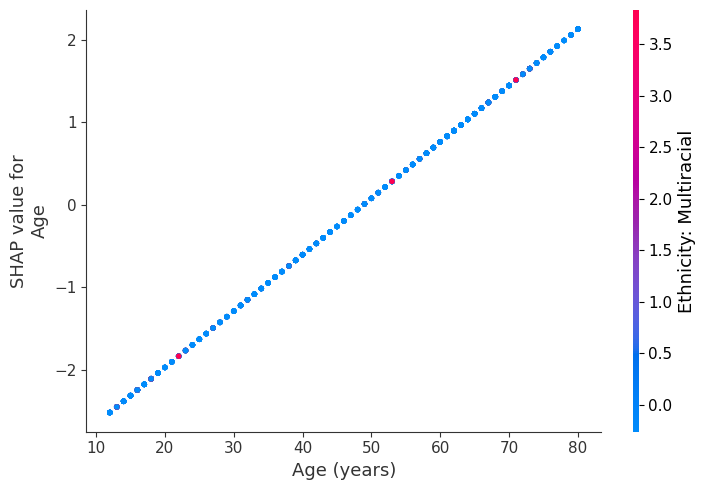

In [203]:

# Using raw age values for clinicians' understanding of the plot
X_test_t_raw = X_test_t.copy()
X_test_t_raw['Age'] = X_test['age'].values  

shap.dependence_plot(
    'Age',
    shap_values.values,
    X_test_t_raw,
    show=False
)
plt.xlabel('Age (years)')
plt.tight_layout()
plt.savefig("shap_dependence_age.png", dpi=150, bbox_inches='tight')
plt.show()

The dependence plot confirms a strong, almost perfect linear relationship between age and its SHAP values.As age increases, the contribution to CKD risk increases. The interaction colouring by Multiracial ethnicity shows almost no variation, suggesting age's effect on CKD risk is largely independent of this ethnicity.

The SHAP analyis provide a clinically interpretable account of the model's decision-making. Age and uric acid were the strongest drivers of CKD across the population. Individual level explanations showed how combinations of features interact for specific patients. This type of explanation could assist healthcare professionals in understanding why a patient has been flagged for confirmatory testing rather than just receiving a binary prediction. It supports clinical decision-making especially in early stage cases of CKD.

## Model Uncertainty and Calibration

The model uncertainty was checked using a calibration curve and Brier Score. For a clinical support tool, well-calibrated probabilities are important.

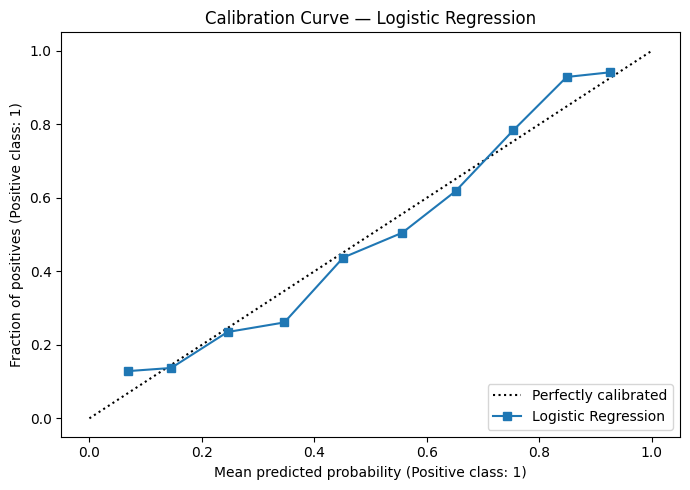

Brier Score: 0.162


In [204]:
# Plotting calibration curve
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(
    y_test, lr_proba,
    n_bins=10,
    ax=ax,
    name='Logistic Regression'
)
ax.set_title('Calibration Curve — Logistic Regression')
plt.tight_layout()
plt.show()

# Brier Score
brier = brier_score_loss(y_test, lr_proba)
print(f'Brier Score: {brier:.3f}')

The calibration curve shows that the predicted probabilities of the model closely follow the diagonal. This indicates that predicted risk scores are well calibrated and can be genuine probabilities. For instance, patients assigned a **70%** predicted probability of CKD were CKD-positive approximately **70%** of the time. This is clinically important because it means clinicians can understand predicted probabilities rather than just arbitrary scores. The Brier Score of **0.162** indicates low prediction error. A well calibrated model supports better clinical decicion-making.

## Subgroup Analysis

Subgroup analysis was performed using recall to evaluate model sensitivity across demographic groups.

In [205]:
# Getting the actual and predicted values
test_df = X_test.copy()
test_df['actual'] = y_test.values
test_df['predicted'] = lr_pred_04
test_df['predicted_proba'] = best_lr.predict_proba(X_test)[:, 1]

results = []

# Calculating metrics for each of the group
ethnicity_cols = [
    'ethnicity_Non-Hispanic Asian',
    'ethnicity_Non-Hispanic Black', 
    'ethnicity_Non-Hispanic White',
    'ethnicity_Other Hispanic',
    'ethnicity_Other/Multiracial'
]

for col in ethnicity_cols:
    group = test_df[test_df[col] == 1]
    if len(group) > 10 and group['actual'].nunique() > 1:
        results.append({
            'Subgroup': col.replace('ethnicity_', 'Ethnicity: '),
            'N': len(group),
            'Recall': round(recall_score(group['actual'], group['predicted']), 3),
            'ROC-AUC': round(roc_auc_score(group['actual'], group['predicted_proba']), 3),
            'F1': round(f1_score(group['actual'], group['predicted']), 3)
        })

# Gender
for val, label in [(1, 'Male'), (0, 'Female')]:
    group = test_df[test_df['gender_Male'] == val]
    if len(group) > 10 and group['actual'].nunique() > 1:
        results.append({
            'Subgroup': f'Gender: {label}',
            'N': len(group),
            'Recall': round(recall_score(group['actual'], group['predicted']), 3),
            'ROC-AUC': round(roc_auc_score(group['actual'], group['predicted_proba']), 3),
            'F1': round(f1_score(group['actual'], group['predicted']), 3)
        })

# Age groups
test_df['age_group'] = pd.cut(
    test_df['age'], 
    bins=[0, 40, 60, 80, 100], 
    labels=['<40', '40-60', '60-80', '80+']
)

for age_grp in ['<40', '40-60', '60-80', '80+']:
    group = test_df[test_df['age_group'] == age_grp]
    if len(group) > 10 and group['actual'].nunique() > 1:
        results.append({
            'Subgroup': f'Age: {age_grp}',
            'N': len(group),
            'Recall': round(recall_score(group['actual'], group['predicted']), 3),
            'ROC-AUC': round(roc_auc_score(group['actual'], group['predicted_proba']), 3),
            'F1': round(f1_score(group['actual'], group['predicted']), 3)
        })

subgroup_df = pd.DataFrame(results)
print(subgroup_df)


                        Subgroup    N  Recall  ROC-AUC     F1
0  Ethnicity: Non-Hispanic Asian   80   0.542    0.821  0.565
1  Ethnicity: Non-Hispanic Black  150   0.865    0.885  0.842
2  Ethnicity: Non-Hispanic White  703   0.855    0.817  0.753
3      Ethnicity: Other Hispanic  147   0.615    0.812  0.646
4   Ethnicity: Other/Multiracial   88   0.865    0.895  0.800
5                   Gender: Male  576   0.848    0.860  0.771
6                 Gender: Female  690   0.771    0.809  0.715
7                       Age: <40  478   0.069    0.596  0.128
8                     Age: 40-60  303   0.698    0.692  0.624
9                     Age: 60-80  485   0.997    0.789  0.838


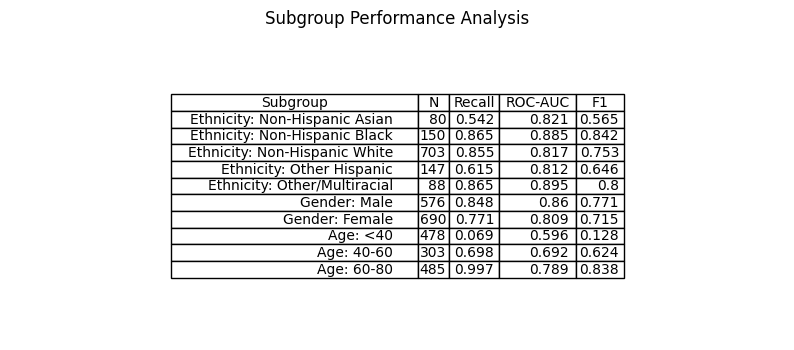

In [206]:
# Plotting a table for subgroups recall
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=subgroup_df.values,
    colLabels=subgroup_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(subgroup_df.columns))))

plt.title("Subgroup Performance Analysis")
plt.show()


In [207]:
ethnicity_df = subgroup_df[subgroup_df['Subgroup'].str.contains('Ethnicity')]
gender_df = subgroup_df[subgroup_df['Subgroup'].str.contains('Gender')]
age_df = subgroup_df[subgroup_df['Subgroup'].str.contains('Age')]

In [208]:
# This function plots recall values across each group
def plot_recall(df, title):
    plt.figure(figsize=(6, 4))
    plt.bar(df['Subgroup'], df['Recall'])
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.title(title)
    plt.ylabel('Recall')
    plt.tight_layout()
    plt.show()

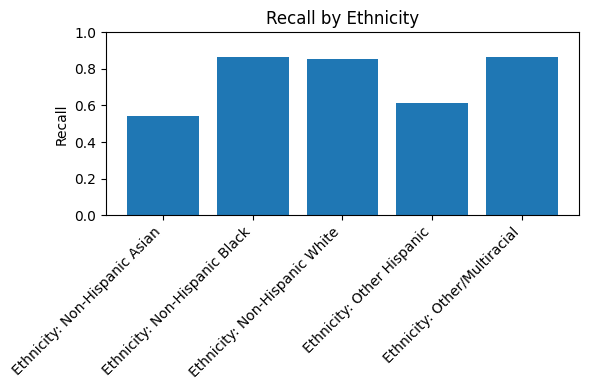

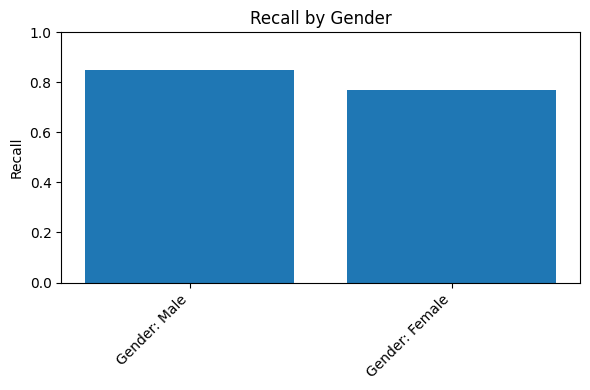

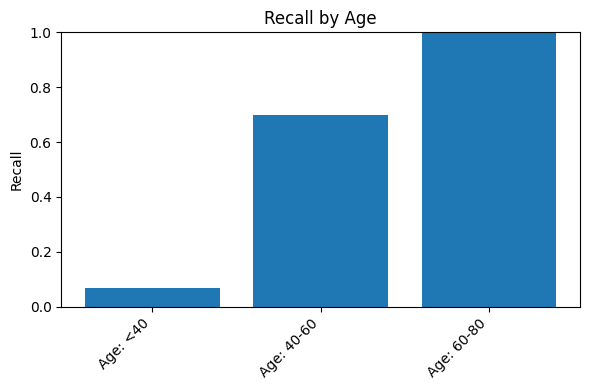

In [209]:
# Calling the function
plot_recall(ethnicity_df, 'Recall by Ethnicity')
plot_recall(gender_df, 'Recall by Gender')
plot_recall(age_df, 'Recall by Age')

Across ethnic groups, differences in recall score was observed. There was lower performance in Non-Hispanic Asian and Other Hispanic groups (approximately **0.6**), compared to higher recall (**>0.8**) in Black, White and Multiracial groups. This suggests that the model may be less effective at identifying CKD cases in certain ethnic subgroups, potentially due to differences in sample size or feature distributions.

Performance across gender was consistent, with only minor differences between males and females, indicating no huge difference in model sensitivity across gender.

For age, recall was very low in individuals under 40 (**<0.2**), but increased highly in older groups, reaching nearly perfect recall in group aged 60–80. This is likely due to the lower prevalence of CKD in younger people. As a result, the model appears to perform better in higher-risk populations, but may struggle to detect early or less typical cases.

## Limitations


Several limitations should be considered when interpreting the results of this classification task on CKD prediction.

- Imputation and encoding were applied before the train–test split. This means that information from the test set could have influenced the training process and slightly inflated model performance.
- The dataset used is a curated subset derived from NHANES rather than raw clinical data. As a result, it may not fully reflect real-world clinical settings, and model performance may differ when applied in practice.
- Although LR performed best, it assumes a linear relationship between predictors and the outcome. This means more complex non-linear interactions between clinical variables may not have been fully captured.
- The dataset also contains a relatively high proportion of CKD cases (approximately 43%), which is higher than real-world prevalence (~14%) (CDC, 2026). This is likely due to the curated nature of the dataset. While this has benefits for model training, it may not reflect real-world screening conditions. As a result, the model may not generalise well to the general population and could overestimate the likelihood of CKD when applied in practice.
- NHANES complex survey weights were not applied in this analysis. Therefore, the results reflect only this study sample and cannot be statistically generalised to the wider United States population.
- Some variables, such as smoking status and diabetes, were self-reported and may be subject to recall bias.


### References 


- CDC. 2026. Chronic Kidney Disease Data and Statistics. https://www.cdc.gov/kidney-disease/php/data-research/index.html
- Dharmarathne, G., Bogahawaththa, M., McAfee, M., Rathnayake, U. and Meddage, D.P.P. 2024. On the diagnosis of chronic kidney disease using a machine learning-based interface with explainable artificial intelligence. Intelligent Systems with Applications 22, 200397. https://doi.org/10.1016/j.iswa.2024.200397
- Du, Y. and Wang, K. 2026. Machine Learning Prediction of Chronic Kidney Disease in Elderly MetS Patients Using NHANES 2011–2020 Data. Rejuvenation Research 29(2), pp.62–72. https://doi.org/10.1177/15491684251399607
- Kidney Care UK. (n.d.) Understanding risk factors of kidney disease. https://kidneycareuk.org/kidney-disease-information/about-kidney-health/understanding-risk-factors-of-kidney-disease/
- Leonberg, K.E., Maski, M.R. and Scott, T.M. et al. 2025. Trends in chronic kidney disease and calories from ultra-processed foods: NHANES at the highly granular level. Discovery Public Health 22, 169. https://doi.org/10.1186/s12982-025-00549-y
- NHS. 2023. Chronic kidney disease. https://www.nhs.uk/conditions/kidney-disease/
- Shah, A. 2023. CKD NHANES 2021–2023 Staged Kidney Disease Dataset. Kaggle. https://www.kaggle.com/datasets/alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease
- Sobrinho, A., Silveira, A., Silva, L., Costa, E., Pinheiro, M. and Perkusich, A. 2020. Computer-Aided Diagnosis of Chronic Kidney Disease in Developing Countries: A Comparative Analysis of Machine Learning Techniques. IEEE Access 8. https://doi.org/10.1109/ACCESS.2020.2971208
- Vart, P., Powe, N.R. and McCulloch, C.E. et al. 2020. National Trends in the Prevalence of Chronic Kidney Disease Among Racial/Ethnic and Socioeconomic Status Groups, 1988-2016. JAMA Network Open 3(7), e207932. https://doi.org/10.1001/jamanetworkopen.2020.7932